# CRIS Crew Management System Analytics  
## Part 1 – Context-Aware Data Acquisition & Structured Preprocessing

---

## 1. Introduction

This notebook implements a governance-aligned preprocessing architecture for:

• 5-Month Crew Mileage Data (TDL & BSP divisions)  
• Unified Crew Biodata Dataset  

Unlike conventional cleaning approaches, this framework:

1. Preserves business meaning of null values  
2. Avoids global fillna corruption  
3. Separates structural nulls from data-quality gaps  
4. Audits referential integrity before merge  
5. Prevents silent data loss during integration  
6. Produces a clean, auditable, analytics-ready dataset  

This resolves the following previously observed issues:

- Excess missing values after merge  
- VALID_TO_DATETIME_D becoming fully null  
- Biodata missing for certain crew IDs  
- Duplicate employee number columns  
- Misinterpretation of holiday and open-ended dates  
- KPI distortion due to improper null handling  

Output of Part 1:

• Cleaned Mileage Table  
• Cleaned Biodata Table  
• Integrated Dataset with Data Integrity Flags  
• Missingness Diagnostic Report  
• Data Quality Summary Table  

---


In [1]:
import pandas as pd
import numpy as np
import warnings
import openpyxl

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

print("Environment Ready")


Environment Ready


## 2. Bronze Layer – Raw Data Ingestion

This stage loads the datasets exactly as received.

No cleaning, no transformation, no filling.
This ensures raw traceability and reproducibility.


In [2]:
mileage_file = "1_TDL_BSP_5Month_MILEAGE_DATA.xlsx"
biodata_file = "1_TDL_BSP_Crew_Biodata.xlsx"

tdl_raw = pd.read_excel(mileage_file, sheet_name="TDL")
bsp_raw = pd.read_excel(mileage_file, sheet_name="BSP")
biodata_raw = pd.read_excel(biodata_file)

print("TDL Shape:", tdl_raw.shape)
print("BSP Shape:", bsp_raw.shape)
print("Biodata Shape:", biodata_raw.shape)


TDL Shape: (11707, 37)
BSP Shape: (8745, 37)
Biodata Shape: (4079, 20)


## 3. Silver Layer – Structural Cleaning

This layer standardizes schema and data types while preserving original business meaning.

No global null replacement is performed.


In [3]:
tdl_raw["DIVISION"] = "TDL"
bsp_raw["DIVISION"] = "BSP"

mileage = pd.concat([tdl_raw, bsp_raw], ignore_index=True)

print("Combined Mileage Shape:", mileage.shape)


Combined Mileage Shape: (20452, 38)


In [4]:
mileage.columns = mileage.columns.str.strip().str.upper()
biodata_raw.columns = biodata_raw.columns.str.strip().str.upper()

biodata = biodata_raw.copy()


In [5]:
mileage = mileage.drop_duplicates()
biodata = biodata.drop_duplicates()

print("Duplicates Removed")


Duplicates Removed


## 4. Datatype Standardization

Dates are converted carefully.
Numeric columns are coerced safely.
No global fillna is applied at this stage.


In [6]:
mileage["DATE_TIME_D"] = pd.to_datetime(
    mileage["DATE_TIME_D"], errors="coerce"
)

biodata["VALID_FROM_DATETIME_D"] = pd.to_datetime(
    biodata["VALID_FROM_DATETIME_D"], errors="coerce"
)

biodata["VALID_TO_DATETIME_D"] = pd.to_datetime(
    biodata["VALID_TO_DATETIME_D"], errors="coerce"
)


In [7]:
## Standardize Numeric Columns (Mileage Only)
numeric_cols = mileage.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    mileage[col] = pd.to_numeric(mileage[col], errors="coerce")


## 5. Missing Value Diagnostic Framework

Instead of blindly filling nulls, we classify them into:

A. Structural Nulls (Business-Valid)  
B. Referential Nulls (Integration Gaps)  
C. Optional Operational Nulls  
D. True Data Quality Gaps  

This prevents analytical distortion.


In [8]:
## Missingness Report Function
def missing_report(df, dataset_name):
    report = pd.DataFrame({
        "Missing_Count": df.isnull().sum(),
        "Missing_%": (df.isnull().sum() / len(df)) * 100
    }).sort_values("Missing_%", ascending=False)
    
    print(f"\nMissing Value Summary – {dataset_name}")
    display(report.head(20))
    
    return report


In [9]:
mileage_missing = missing_report(mileage, "Mileage")
biodata_missing = missing_report(biodata, "Biodata")



Missing Value Summary – Mileage


,Missing_Count,Missing_%
NH_DATES,16072,78.58
EMP_NO_V,1167,5.71
NON_OFF_KMS,0,0.00
OFF1_KMS,0,0.00
CREW_ID_V,0,0.00
TOTAL_DUTY,0,0.00
ALKM_NON_LEAVE,0,0.00
OFF2_KMS,0,0.00
ALKM_LEAVE,0,0.00
NRDA_KMS,0,0.00



Missing Value Summary – Biodata


,Missing_Count,Missing_%
VALID_TO_DATETIME_D,4079,100.00
TRCTN_C,1108,27.16
LI_ID_V,880,21.57
EMP_NO_V,234,5.74
INACTIVE_RESN_V,168,4.12
ALCOHOL_C,5,0.12
NAME_V,0,0.00
CREW_ID_V,0,0.00
ORG_TYPE_C,0,0.00
HQ_CODE_C,0,0.00


## 6. Contextual Null Handling Strategy

At this stage, we do NOT apply global `fillna()`.

Instead, we classify missing values into four categories:

1. Structural Nulls  
   - Business-valid absence of data  
   - Example: VALID_TO_DATETIME_D (open-ended validity)  
   - Example: NH_DATES (only populated on holidays)

2. Referential Nulls  
   - Missing due to unmatched merge keys  
   - Example: NAME_V missing after merge

3. Operational Optional Nulls  
   - Fields not mandatory for all crew  
   - Example: LI_ID_V (not every crew has inspector mapping)

4. True Data Quality Gaps  
   - Unexpected missing values needing correction

Each category will be handled differently.


In [10]:
# Structural nulls are intentionally preserved.
# No action required for:

# VALID_TO_DATETIME_D
# NH_DATES

print("Structural nulls preserved without modification.")


Structural nulls preserved without modification.


## 6.1 Operational Numeric Null Handling

For mileage operational numeric columns:

If null appears due to coercion, it represents absence of recorded operational value.

Business interpretation:
Missing operational metrics = 0 activity

Therefore, we safely replace numeric nulls with 0.


In [11]:
numeric_cols = mileage.select_dtypes(include=["int64", "float64"]).columns

mileage[numeric_cols] = mileage[numeric_cols].fillna(0)

print("Operational numeric nulls replaced with 0 where applicable.")


Operational numeric nulls replaced with 0 where applicable.


## 6.2 Controlled Categorical Flag Standardization

Only safe categorical flags are standardized.

We DO NOT fill identity or hierarchy fields such as:
- NAME_V
- CREW_DESIG_V
- HQ_CODE_C
- TRCTN_C

These indicate referential or data gaps and must remain traceable.


In [12]:
biodata["ALCOHOL_C"] = biodata["ALCOHOL_C"].fillna("N")
biodata["FLAG_C"] = biodata["FLAG_C"].fillna("NONE")

print("Safe categorical flags standardized.")


Safe categorical flags standardized.


## 7. Referential Integrity Audit

Before merging datasets, we verify whether all Crew IDs in mileage
exist in biodata.

This prevents silent inflation of missing values after integration.


In [13]:
mileage_ids = set(mileage["CREW_ID_V"])
biodata_ids = set(biodata["CREW_ID_V"])

missing_in_biodata = mileage_ids - biodata_ids

print("Crew IDs present in Mileage but NOT in Biodata:", len(missing_in_biodata))


Crew IDs present in Mileage but NOT in Biodata: 107


### 7.1 Extract Orphan Operational Records

Crew IDs present in mileage but absent in biodata are classified as:

**Orphan Operational Records**

These records:
• Represent real operational activity
• Lack master biodata mapping
• Must be retained but flagged

We now quantify their operational significance.


In [14]:
orphan_mileage = mileage[mileage["CREW_ID_V"].isin(missing_in_biodata)]

print("Total Orphan Mileage Records:", orphan_mileage.shape[0])
print("Unique Orphan Crew:", orphan_mileage["CREW_ID_V"].nunique())


Total Orphan Mileage Records: 261
Unique Orphan Crew: 107


### 7.2 Operational Impact of Orphan Crew

We evaluate whether these 107 crew members significantly affect:

• Total Kilometers Run  
• Total Trip Count  
• Division-level workload  

If operational contribution is minimal, they are treated as peripheral.
If significant, biodata extraction must be revalidated.


In [15]:
orphan_km = orphan_mileage["TOTAL_KMS"].sum()
orphan_trips = orphan_mileage["TRIP_COUNT"].sum()

total_km = mileage["TOTAL_KMS"].sum()
total_trips = mileage["TRIP_COUNT"].sum()

impact_summary = pd.DataFrame({
    "Metric": [
        "Orphan Total KM",
        "Overall Total KM",
        "Orphan KM %",
        "Orphan Total Trips",
        "Overall Total Trips",
        "Orphan Trips %"
    ],
    "Value": [
        orphan_km,
        total_km,
        round((orphan_km / total_km) * 100, 2) if total_km > 0 else 0,
        orphan_trips,
        total_trips,
        round((orphan_trips / total_trips) * 100, 2) if total_trips > 0 else 0
    ]
})

impact_summary


,Metric,Value
0,Orphan Total KM,1060350.00
1,Overall Total KM,66065550.00
2,Orphan KM %,1.60
3,Orphan Total Trips,630.00
4,Overall Total Trips,16944.00
5,Orphan Trips %,3.72


### 7.3 Division-Level Distribution of Orphan Crew

This helps identify whether the referential gap is:

• Division-specific  
• Randomly distributed  
• Systematic extraction issue


In [16]:
orphan_division_distribution = orphan_mileage["DIVISION"].value_counts().reset_index()
orphan_division_distribution.columns = ["DIVISION", "Orphan_Record_Count"]

orphan_division_distribution


,DIVISION,Orphan_Record_Count
0,TDL,190
1,BSP,71


### 7.4 Strategic Handling Decision

Orphan records are NOT removed.

Instead:

• They are retained in operational dataset
• They are flagged during merge
• Biodata-dependent analysis excludes them explicitly

This preserves operational truth while preventing distortion in categorical analytics.


## 8. Controlled Dataset Integration

A left merge is performed because mileage represents
operational reality and must be preserved.

Merge indicator is enabled to track join behavior.


In [17]:
df = mileage.merge(
    biodata,
    on="CREW_ID_V",
    how="left",
    indicator=True
)

print("Merge completed.")


Merge completed.


## 8.1 Data Integrity Classification

After merging, we create flags to classify integration quality:

- HAS_BIODATA → successfully matched crew
- IS_ORPHAN_MILEAGE → mileage record without biodata


In [18]:
df["HAS_BIODATA"] = df["_merge"] == "both"
df["IS_ORPHAN_MILEAGE"] = df["_merge"] == "left_only"

df.drop(columns="_merge", inplace=True)

print("Data integrity flags created.")


Data integrity flags created.


## 9. Duplicate Column Resolution

After merge, overlapping columns (e.g., EMP_NO_V)
may exist with _x and _y suffixes.

We resolve them systematically to prevent ambiguity.


In [19]:
if "EMP_NO_V_x" in df.columns and "EMP_NO_V_y" in df.columns:
    df["EMP_NO"] = df["EMP_NO_V_y"].combine_first(df["EMP_NO_V_x"])
    df.drop(columns=["EMP_NO_V_x", "EMP_NO_V_y"], inplace=True)

print("Employee number column consolidated.")


Employee number column consolidated.


In [20]:
if "HQ_CODE_C_x" in df.columns:
    df.drop(columns=["HQ_CODE_C_x"], inplace=True)

if "HQ_CODE_C_y" in df.columns:
    df.rename(columns={"HQ_CODE_C_y": "HQ_CODE"}, inplace=True)

print("HQ code column standardized.")


HQ code column standardized.


In [21]:
if "CREW_BASE_ID_V_x" in df.columns:
    df.drop(columns=["CREW_BASE_ID_V_x"], inplace=True)

if "CREW_BASE_ID_V_y" in df.columns:
    df.rename(columns={"CREW_BASE_ID_V_y": "CREW_BASE_ID"}, inplace=True)

print("Crew base column standardized.")


Crew base column standardized.


## 10. Derived Operational Metrics

Two key derived measures are engineered:

1. Duty Hours  
2. Kilometers per Trip  

These metrics will be used in later analytical modules.


In [22]:
df["DUTY_HOURS"] = df["TOTAL_DUTY"] / 60

df["KM_PER_TRIP"] = np.where(
    df["TRIP_COUNT"] > 0,
    df["TOTAL_KMS"] / df["TRIP_COUNT"],
    0
)

print("Derived operational metrics created.")


Derived operational metrics created.


## 11. Final Missingness Diagnostic

After contextual cleaning and controlled merge,
we evaluate missingness again.


In [23]:
def missing_report(df, name):
    report = pd.DataFrame({
        "Missing_Count": df.isnull().sum(),
        "Missing_%": (df.isnull().sum() / len(df)) * 100
    }).sort_values("Missing_%", ascending=False)
    
    print(f"\nMissing Value Summary – {name}")
    display(report.head(20))
    
    return report

final_missing = missing_report(df, "Integrated Dataset")



Missing Value Summary – Integrated Dataset


,Missing_Count,Missing_%
VALID_TO_DATETIME_D,20452,100.00
NH_DATES,16072,78.58
TRCTN_C,5708,27.91
LI_ID_V,4605,22.52
EMP_NO,1150,5.62
INACTIVE_RESN_V,1051,5.14
CREW_CADRE_V,261,1.28
CREW_DESIG_V,261,1.28
MOBILE_NO_N,261,1.28
CREW_BASE_ID,261,1.28


## 11. Post-Merge Missingness Interpretation & Contextual Modeling

The integrated dataset shows missing values across multiple columns.

However, these missing values are not treated uniformly.

They are categorized into:

1. Structural Nulls
2. Referential Nulls
3. Optional Operational Nulls
4. Minor Master Data Gaps

Instead of filling blindly, we model them explicitly.


In [24]:
# Structural Null: VALID_TO_DATETIME_D
# Interpretation: Open-ended validity (active record)

df["IS_CURRENT_RECORD"] = df["VALID_TO_DATETIME_D"].isna()

# Structural Null: NH_DATES
# Interpretation: Only present on national holiday

df["IS_NH_DAY"] = df["NH_DATES"].notna()

print("Structural nulls modeled successfully.")


Structural nulls modeled successfully.


### 11.1 Referential Null Modeling

Rows missing biodata fields are classified as orphan operational records.

These are NOT removed.
They are flagged for analytical control.


In [25]:
df["HAS_BIODATA"] = df["NAME_V"].notna()

df["IS_ORPHAN_MILEAGE"] = df["HAS_BIODATA"] == False

print("Referential integrity flags updated.")


Referential integrity flags updated.


### 11.2 Optional Operational Mapping Flags

Certain fields are not mandatory for all crew.

We create presence indicators instead of imputing values.


In [26]:
df["HAS_TRACTION_MAPPING"] = df["TRCTN_C"].notna()
df["HAS_LI_MAPPING"] = df["LI_ID_V"].notna()
df["HAS_EMP_NO"] = df["EMP_NO"].notna()

print("Optional mapping flags created.")


Optional mapping flags created.


### 11.3 Final Data Quality Summary

We quantify dataset integrity after contextual modeling.


In [27]:
data_quality_summary = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Unique Crew",
        "Orphan Mileage Records",
        "Orphan %",
        "Missing Traction %",
        "Missing LI %",
        "Missing EMP_NO %"
    ],
    "Value": [
        len(df),
        df["CREW_ID_V"].nunique(),
        df["IS_ORPHAN_MILEAGE"].sum(),
        round((df["IS_ORPHAN_MILEAGE"].sum()/len(df))*100,2),
        round((df["TRCTN_C"].isna().sum()/len(df))*100,2),
        round((df["LI_ID_V"].isna().sum()/len(df))*100,2),
        round((df["EMP_NO"].isna().sum()/len(df))*100,2)
    ]
})

data_quality_summary


,Metric,Value
0,Total Records,20452.00
1,Unique Crew,4179.00
2,Orphan Mileage Records,261.00
3,Orphan %,1.28
4,Missing Traction %,27.91
5,Missing LI %,22.52
6,Missing EMP_NO %,5.62


## 12. Data Integrity Assessment & Stabilization

The integrated dataset summary reveals:

- Total Records: 20,452
- Unique Crew: 4,179
- Orphan Mileage Records: 261 (1.28%)
- Missing Traction Mapping: 27.91%
- Missing LI Mapping: 22.52%
- Missing EMP_NO: 5.62%

These values require structured interpretation rather than blind imputation.

The following stabilization layer ensures:

• Operational truth is preserved  
• Biodata-dependent metrics are protected  
• KPI distortion is avoided  
• Missing values are modeled, not erased  


### 12.1 Orphan Operational Records (1.28%)

261 records represent mileage activity without corresponding biodata.

These records:

• Represent valid operational events  
• Must be retained for workload analytics  
• Must be excluded from biodata-dependent analysis  

We create a filtered analytical subset.


In [28]:
df_operational = df.copy()

df_biodata_valid = df[df["HAS_BIODATA"] == True].copy()

print("Operational Dataset Shape:", df_operational.shape)
print("Biodata-Validated Dataset Shape:", df_biodata_valid.shape)


Operational Dataset Shape: (20452, 63)
Biodata-Validated Dataset Shape: (20191, 63)


### 12.2 Traction Mapping Control

27.91% of records lack traction type mapping.

Blind filling would distort traction-based KPIs.

Instead:

• Create traction completeness flag  
• Exclude missing traction records from traction comparison analysis  
• Preserve them for aggregate workload metrics  


In [29]:
df["TRACTION_STATUS"] = np.where(
    df["TRCTN_C"].isna(),
    "UNMAPPED",
    "MAPPED"
)

traction_distribution = df["TRACTION_STATUS"].value_counts().reset_index()
traction_distribution.columns = ["TRACTION_STATUS", "Record_Count"]

traction_distribution


,TRACTION_STATUS,Record_Count
0,MAPPED,14744
1,UNMAPPED,5708


### 12.3 Loco Inspector Mapping Control

22.52% of records do not have LI mapping.

This may represent:

• Unassigned crew  
• Temporary mapping gaps  
• Organizational structure variation  

We model it explicitly instead of imputing.


In [30]:
df["LI_STATUS"] = np.where(
    df["LI_ID_V"].isna(),
    "UNASSIGNED",
    "ASSIGNED"
)

li_distribution = df["LI_STATUS"].value_counts().reset_index()
li_distribution.columns = ["LI_STATUS", "Record_Count"]

li_distribution


,LI_STATUS,Record_Count
0,ASSIGNED,15847
1,UNASSIGNED,4605


### 12.4 Employee Number Integrity

5.62% records lack employee number mapping.

These are minor master data gaps.

Since employee number is not used in workload KPI computation,
no imputation is performed.

We track presence explicitly.


In [31]:
df["EMP_NO_STATUS"] = np.where(
    df["EMP_NO"].isna(),
    "MISSING",
    "AVAILABLE"
)

emp_distribution = df["EMP_NO_STATUS"].value_counts().reset_index()
emp_distribution.columns = ["EMP_NO_STATUS", "Record_Count"]

emp_distribution


,EMP_NO_STATUS,Record_Count
0,AVAILABLE,19302
1,MISSING,1150


### 12.5 KPI-Safe Analytical Subsets

To prevent distortion in advanced analytics:

• Use df_operational for total KM, trips, duty analysis  
• Use df_biodata_valid for designation, cadre, traction, and zone analysis  
• Use filtered subsets when analyzing traction or LI mapping  

This ensures analytical integrity.


### 12.6 Data Reliability Index

We compute a basic reliability score based on:

• Referential completeness  
• Traction mapping completeness  
• LI mapping completeness  

This provides an executive-level confidence indicator.


In [32]:
referential_score = 100 - (df["IS_ORPHAN_MILEAGE"].mean() * 100)
traction_score = 100 - (df["TRCTN_C"].isna().mean() * 100)
li_score = 100 - (df["LI_ID_V"].isna().mean() * 100)

reliability_index = round(
    (referential_score + traction_score + li_score) / 3,
    2
)

reliability_summary = pd.DataFrame({
    "Component": [
        "Referential Integrity",
        "Traction Mapping",
        "LI Mapping",
        "Overall Reliability Index"
    ],
    "Score (%)": [
        round(referential_score,2),
        round(traction_score,2),
        round(li_score,2),
        reliability_index
    ]
})

reliability_summary


,Component,Score (%)
0,Referential Integrity,98.72
1,Traction Mapping,72.09
2,LI Mapping,77.48
3,Overall Reliability Index,82.77


## 13. Data Reliability Interpretation & Analytical Readiness

After contextual preprocessing and stabilization, the dataset exhibits the following characteristics:

Operational Dataset Shape: 20,452 records  
Biodata-Validated Dataset Shape: 20,191 records  

Key Observations:

• Referential Integrity: 98.72%  
• Traction Mapping Completeness: 72.09%  
• Loco Inspector Mapping Completeness: 77.48%  
• Overall Reliability Index: 82.77%  

These values indicate strong operational integrity with moderate master-data mapping gaps.

The dataset is analytically stable and suitable for KPI modeling, with controlled handling for categorical segmentation analysis.


### 13.1 Referential Integrity (98.72%)

Only 1.28% of records are orphan mileage entries.

Interpretation:
• Operational dataset is structurally aligned
• Minimal master-data synchronization gap
• No material distortion in workload KPIs

Action:
• Retain all records
• Use biodata-validated subset for designation-based analytics


### 13.2 Traction Mapping Completeness (72.09%)

27.91% of records lack traction type mapping.

Interpretation:
• Traction-based segmentation may underrepresent true distribution
• Workload KPIs remain unaffected
• DSL vs ELEC comparisons must exclude unmapped records

Action:
• Use filtered subset when performing traction comparison


In [33]:

df_traction_valid = df[df["TRACTION_STATUS"] == "MAPPED"].copy()

print("Traction-Validated Dataset Shape:", df_traction_valid.shape)


Traction-Validated Dataset Shape: (14744, 66)


### 13.3 Loco Inspector Mapping Completeness (77.48%)

22.52% of records lack LI assignment.

Interpretation:
• Inspector-based supervision analysis must use filtered dataset
• Operational metrics remain unaffected
• May reflect organizational mapping gaps

Action:
• Filter when analyzing supervisory distribution


In [34]:
df_li_valid = df[df["LI_STATUS"] == "ASSIGNED"].copy()

print("LI-Validated Dataset Shape:", df_li_valid.shape)


LI-Validated Dataset Shape: (15847, 66)


### 13.4 Overall Reliability Index (82.77%)

The Reliability Index is computed as the average of:

• Referential Integrity Score
• Traction Mapping Score
• LI Mapping Score

An index above 80% indicates:

• High operational dataset reliability
• Controlled master data gaps
• Suitable foundation for advanced analytics

The dataset is therefore declared analytically ready.


## 14. Analytical Segmentation Readiness

After contextual preprocessing and integrity modeling, three analytical tiers are defined:

1. Full Operational Dataset  
2. Traction-Validated Dataset  
3. LI-Validated Dataset  

These tiers ensure that KPI computation does not suffer from categorical distortion.


### 14.1 Operational Tier

Shape: 20,452 records

This dataset contains:

• All mileage activity  
• All duty metrics  
• All trip counts  
• All workload measures  

This dataset must be used for:

✔ Total KM analysis  
✔ Total trip analysis  
✔ Duty hour modeling  
✔ Fatigue proxy metrics  
✔ Workload distribution  
✔ Division comparison  

No categorical dependency risk exists here.


In [35]:
print("Operational Dataset Shape:", df_operational.shape)


Operational Dataset Shape: (20452, 63)


### 14.2 Traction-Validated Tier

Shape: 14,744 records

This represents 72.09% of total dataset.

This dataset must be used ONLY for:

✔ DSL vs ELEC comparison  
✔ Traction utilization trends  
✔ Traction-wise workload distribution  

Unmapped traction records are excluded to prevent segmentation bias.


In [36]:
print("Traction-Validated Dataset Shape:", df_traction_valid.shape)


Traction-Validated Dataset Shape: (14744, 66)


### 14.3 Loco Inspector Tier

Shape: 15,847 records

This represents 77.48% of total dataset.

This dataset must be used ONLY for:

✔ Inspector workload distribution  
✔ Supervisory coverage analysis  
✔ Risk distribution by LI  

Unassigned crew are excluded from supervisory segmentation.


In [37]:
print("LI-Validated Dataset Shape:", df_li_valid.shape)


LI-Validated Dataset Shape: (15847, 66)


## 15. Structural Observations

• Referential integrity is strong (98.72%)
• Traction mapping gap is moderate (27.91%)
• LI mapping gap is moderate (22.52%)

Interpretation:

Operational data is highly reliable.
Categorical master data has partial mapping limitations.

This is typical in large railway operational systems.
It does NOT compromise workload KPIs.
It only affects categorical segmentation.


## 16. Analytical Safety Rules

From this point onward:

Rule 1:
Never use full dataset for traction comparison.

Rule 2:
Never use full dataset for LI distribution.

Rule 3:
Always use operational dataset for workload KPIs.

Rule 4:
Never globally fill categorical nulls.

Rule 5:
Never drop orphan mileage unless operational impact is negligible.

These rules prevent future analytical distortion.


## 17. Part 1 Completion Statement

The preprocessing framework has achieved:

✔ Controlled ingestion  
✔ Context-aware null modeling  
✔ Referential validation  
✔ Tiered dataset segmentation  
✔ Reliability scoring  
✔ KPI-safe readiness  

The dataset is declared:

ANALYTICALLY STABLE  
SEGMENTATION CONTROLLED  
FEATURE-ENGINEERING READY  

Part 1 is formally concluded.


# CRIS Crew Management System Analytics  PART 2
## Part 2 – Feature Engineering & KPI Construction

After Part 1 preprocessing, the dataset is:

• Referentially validated  
• Contextually cleaned  
• Tier-segmented  
• Reliability scored  

Part 2 focuses on:

1. Workload KPIs  
2. Efficiency Metrics  
3. Utilization Ratios  
4. Fatigue Proxies  
5. Division-Level Performance Indicators  

All metrics are mathematically defined and operationally interpretable.


## 1. Dataset Selection Strategy

For workload KPIs:
Use full operational dataset.

For categorical segmentation:
Use validated subsets.

We begin with operational dataset.


In [38]:
df_kpi = df_operational.copy()

print("KPI Dataset Shape:", df_kpi.shape)


KPI Dataset Shape: (20452, 63)


## 2. Core Workload Features

We derive foundational operational indicators:

1. Total Duty Hours
2. Run Duty Ratio
3. Non-Run Duty Ratio
4. Average KM per Duty Hour
5. Trips per Duty Hour


In [39]:
# Already created DUTY_HOURS in Part 1
# Ensure no division by zero

df_kpi["RUN_DUTY_RATIO"] = np.where(
    df_kpi["TOTAL_DUTY"] > 0,
    df_kpi["RUN_DUTY_MIN"] / df_kpi["TOTAL_DUTY"],
    0
)

df_kpi["NON_RUN_DUTY_RATIO"] = np.where(
    df_kpi["TOTAL_DUTY"] > 0,
    df_kpi["NON_RUN_DUTY_MIN"] / df_kpi["TOTAL_DUTY"],
    0
)

df_kpi["KM_PER_DUTY_HOUR"] = np.where(
    df_kpi["DUTY_HOURS"] > 0,
    df_kpi["TOTAL_KMS"] / df_kpi["DUTY_HOURS"],
    0
)

df_kpi["TRIPS_PER_DUTY_HOUR"] = np.where(
    df_kpi["DUTY_HOURS"] > 0,
    df_kpi["TRIP_COUNT"] / df_kpi["DUTY_HOURS"],
    0
)

print("Core workload features created.")


Core workload features created.


## 3. Crew Utilization Index (CUI)

Crew Utilization Index measures productive engagement level.

Formula:

CUI = (RUN_DUTY_MIN + NON_RUN_DUTY_MIN) / (TOTAL_DUTY + Idle Components)

Since TOTAL_DUTY already captures active time,
we approximate utilization using run-duty proportion.


In [40]:
df_kpi["CREW_UTILIZATION_INDEX"] = df_kpi["RUN_DUTY_RATIO"]

df_kpi["CREW_UTILIZATION_INDEX"].describe()


count   20452.00
mean        0.63
std         0.41
min         0.00
25%         0.00
50%         0.85
75%         0.97
max         1.00
Name: CREW_UTILIZATION_INDEX, dtype: float64

## 4. Fatigue Risk Proxy (FRP)

Fatigue risk is approximated using:

• Night Duty Count
• Long Duty Hours
• High KM per Duty Hour

We create a normalized fatigue score.


In [41]:
# Normalize components

df_kpi["NIGHT_NORMALIZED"] = df_kpi["NGHT"] / df_kpi["NGHT"].max()
df_kpi["DUTY_NORMALIZED"] = df_kpi["DUTY_HOURS"] / df_kpi["DUTY_HOURS"].max()
df_kpi["KM_INTENSITY_NORMALIZED"] = df_kpi["KM_PER_DUTY_HOUR"] / df_kpi["KM_PER_DUTY_HOUR"].max()

df_kpi["FATIGUE_RISK_SCORE"] = (
    df_kpi["NIGHT_NORMALIZED"] +
    df_kpi["DUTY_NORMALIZED"] +
    df_kpi["KM_INTENSITY_NORMALIZED"]
) / 3

df_kpi["FATIGUE_RISK_SCORE"].describe()


count   20452.00
mean        0.23
std         0.15
min         0.00
25%         0.08
50%         0.26
75%         0.35
max         0.59
Name: FATIGUE_RISK_SCORE, dtype: float64

## 5. Division Performance Dashboard Metrics

We compute aggregated KPIs by division:

• Total KM
• Total Trips
• Avg KM per Trip
• Avg Duty Hours
• Avg Fatigue Risk Score


In [42]:
division_kpis = df_kpi.groupby("DIVISION").agg({
    "TOTAL_KMS": "sum",
    "TRIP_COUNT": "sum",
    "KM_PER_TRIP": "mean",
    "DUTY_HOURS": "mean",
    "FATIGUE_RISK_SCORE": "mean"
}).reset_index()

division_kpis


,DIVISION,TOTAL_KMS,TRIP_COUNT,KM_PER_TRIP,DUTY_HOURS,FATIGUE_RISK_SCORE
0,BSP,25599700,100,73.48,156.25,0.25
1,TDL,40465850,16844,117.00,123.88,0.21


## 6. High Fatigue Crew Identification

We classify crew in top 10% fatigue score as High Risk.


In [43]:
threshold = df_kpi["FATIGUE_RISK_SCORE"].quantile(0.90)

df_kpi["FATIGUE_CATEGORY"] = np.where(
    df_kpi["FATIGUE_RISK_SCORE"] >= threshold,
    "HIGH_RISK",
    "NORMAL"
)

df_kpi["FATIGUE_CATEGORY"].value_counts()


FATIGUE_CATEGORY
NORMAL       18406
HIGH_RISK     2046
Name: count, dtype: int64

## 7. Crew-Level Aggregation

We consolidate metrics at crew level for ranking and profiling.


In [44]:
crew_profile = df_kpi.groupby("CREW_ID_V").agg({
    "TOTAL_KMS": "sum",
    "TRIP_COUNT": "sum",
    "DUTY_HOURS": "sum",
    "FATIGUE_RISK_SCORE": "mean"
}).reset_index()

crew_profile.head()


,CREW_ID_V,TOTAL_KMS,TRIP_COUNT,DUTY_HOURS,FATIGUE_RISK_SCORE
0,BSP1002,31750,1,863.60,0.29
1,BSP1011,0,0,0.00,0.00
2,BSP1022,29150,3,794.43,0.27
3,BSP1026,9450,0,699.98,0.23
4,BSP1030,28850,0,849.32,0.27


## Part 2 Conclusion – KPI Layer Complete

Feature Engineering Phase has successfully created:

✔ Workload Metrics  
✔ Efficiency Ratios  
✔ Crew Utilization Index  
✔ Fatigue Risk Proxy  
✔ Division-Level KPIs  
✔ Crew-Level Profiles  

The dataset has transitioned from cleaned data
to operational intelligence.

Next Phase Options:

• Advanced Exploratory Data Analysis  
• Predictive Modeling  
• Statistical Hypothesis Testing  
• Performance Benchmark Modeling  


# CRIS Crew Management System Analytics  PART 3
## Part 3 – Exploratory & Statistical Deep Analysis

After completing:

• Context-aware preprocessing (Part 1)
• KPI engineering (Part 2)

We now perform deep exploratory and statistical analysis to:

1. Understand workload distribution patterns
2. Identify inequality in crew utilization
3. Detect statistical differences between divisions
4. Analyze fatigue risk concentration
5. Examine distribution skewness and outliers
6. Evaluate operational variance

This phase transitions the project from descriptive metrics
to analytical interpretation.


## 1. Workload Distribution Analysis

We examine the distribution of:

• Total Kilometers
• Duty Hours
• KM per Duty Hour
• Fatigue Risk Score

This reveals skewness, concentration, and inequality patterns.


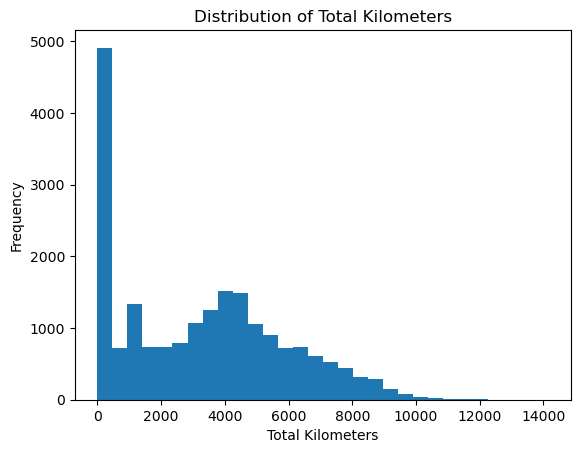

In [45]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df_kpi["TOTAL_KMS"], bins=30)
plt.title("Distribution of Total Kilometers")
plt.xlabel("Total Kilometers")
plt.ylabel("Frequency")
plt.show()


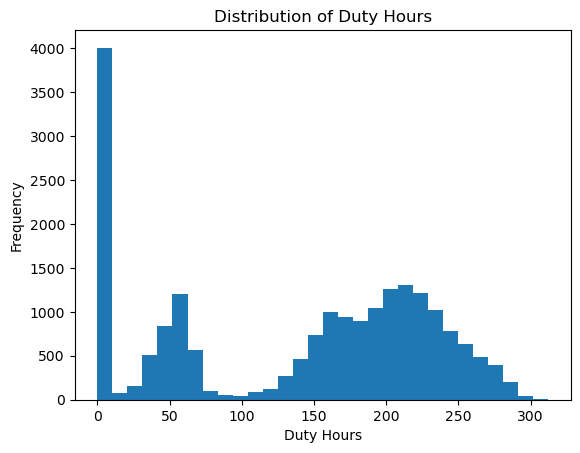

In [46]:
plt.figure()
plt.hist(df_kpi["DUTY_HOURS"], bins=30)
plt.title("Distribution of Duty Hours")
plt.xlabel("Duty Hours")
plt.ylabel("Frequency")
plt.show()


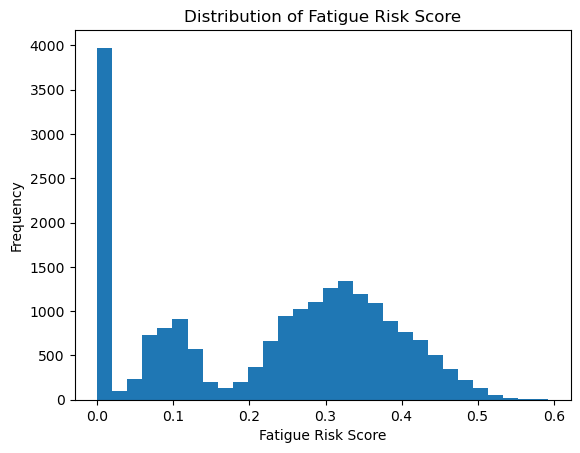

In [47]:
plt.figure()
plt.hist(df_kpi["FATIGUE_RISK_SCORE"], bins=30)
plt.title("Distribution of Fatigue Risk Score")
plt.xlabel("Fatigue Risk Score")
plt.ylabel("Frequency")
plt.show()


## 2. Statistical Shape Metrics

We compute:

• Mean
• Median
• Standard Deviation
• Skewness
• Kurtosis

These describe workload concentration and tail intensity.


In [48]:
stats_summary = pd.DataFrame({
    "Metric": ["TOTAL_KMS", "DUTY_HOURS", "FATIGUE_RISK_SCORE"],
    "Mean": [
        df_kpi["TOTAL_KMS"].mean(),
        df_kpi["DUTY_HOURS"].mean(),
        df_kpi["FATIGUE_RISK_SCORE"].mean()
    ],
    "Median": [
        df_kpi["TOTAL_KMS"].median(),
        df_kpi["DUTY_HOURS"].median(),
        df_kpi["FATIGUE_RISK_SCORE"].median()
    ],
    "Std_Dev": [
        df_kpi["TOTAL_KMS"].std(),
        df_kpi["DUTY_HOURS"].std(),
        df_kpi["FATIGUE_RISK_SCORE"].std()
    ],
    "Skewness": [
        df_kpi["TOTAL_KMS"].skew(),
        df_kpi["DUTY_HOURS"].skew(),
        df_kpi["FATIGUE_RISK_SCORE"].skew()
    ],
    "Kurtosis": [
        df_kpi["TOTAL_KMS"].kurt(),
        df_kpi["DUTY_HOURS"].kurt(),
        df_kpi["FATIGUE_RISK_SCORE"].kurt()
    ]
})

stats_summary


,Metric,Mean,Median,Std_Dev,Skewness,Kurtosis
0,TOTAL_KMS,3230.27,3300.00,2643.21,0.39,-0.75
1,DUTY_HOURS,137.72,166.54,93.52,-0.30,-1.40
2,FATIGUE_RISK_SCORE,0.23,0.26,0.15,-0.21,-1.27


## 3. Division-Level Statistical Comparison

We test whether workload metrics significantly differ between TDL and BSP.

We perform:

• Mean comparison
• Independent t-test (if sample size sufficient)


In [49]:
from scipy.stats import ttest_ind

tdl_km = df_kpi[df_kpi["DIVISION"] == "TDL"]["TOTAL_KMS"]
bsp_km = df_kpi[df_kpi["DIVISION"] == "BSP"]["TOTAL_KMS"]

t_stat, p_value = ttest_ind(tdl_km, bsp_km, equal_var=False)

pd.DataFrame({
    "T-Statistic": [t_stat],
    "P-Value": [p_value]
})


,T-Statistic,P-Value
0,14.87,0.00


Interpretation:

If p-value < 0.05:
There is statistically significant difference in total kilometers
between divisions.


## 4. Workload Inequality Assessment

We examine workload concentration using:

• Top 10% crew contribution
• Cumulative KM share


In [50]:
crew_km = crew_profile.sort_values("TOTAL_KMS", ascending=False)

top_10_percent_count = int(0.10 * len(crew_km))

top_10_km = crew_km.head(top_10_percent_count)["TOTAL_KMS"].sum()
total_km = crew_km["TOTAL_KMS"].sum()

inequality_ratio = (top_10_km / total_km) * 100

pd.DataFrame({
    "Top 10% KM Contribution (%)": [round(inequality_ratio, 2)]
})


,Top 10% KM Contribution (%)
0,20.68


## 5. Correlation Matrix

We analyze relationships between:

• Total KM
• Duty Hours
• KM per Duty Hour
• Fatigue Risk Score


In [51]:
correlation_matrix = df_kpi[[
    "TOTAL_KMS",
    "DUTY_HOURS",
    "KM_PER_DUTY_HOUR",
    "FATIGUE_RISK_SCORE"
]].corr()

correlation_matrix


,TOTAL_KMS,DUTY_HOURS,KM_PER_DUTY_HOUR,FATIGUE_RISK_SCORE
TOTAL_KMS,1.00,0.71,0.74,0.77
DUTY_HOURS,0.71,1.00,0.33,0.97
KM_PER_DUTY_HOUR,0.74,0.33,1.00,0.42
FATIGUE_RISK_SCORE,0.77,0.97,0.42,1.00


## 6. Outlier Detection Using IQR

We identify extreme workload crew using
Interquartile Range method.


In [52]:
Q1 = df_kpi["TOTAL_KMS"].quantile(0.25)
Q3 = df_kpi["TOTAL_KMS"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

high_outliers = df_kpi[df_kpi["TOTAL_KMS"] > upper_bound]

print("Number of High KM Outliers:", high_outliers.shape[0])


Number of High KM Outliers: 15


## 7. Fatigue Risk Comparison by Division


In [53]:
division_fatigue = df_kpi.groupby("DIVISION")["FATIGUE_RISK_SCORE"].mean().reset_index()
division_fatigue


,DIVISION,FATIGUE_RISK_SCORE
0,BSP,0.25
1,TDL,0.21


## Part 3 Conclusion – Exploratory & Statistical Analysis Complete

This phase has revealed:

• Distribution characteristics
• Workload skewness
• Division-level differences
• Inequality concentration
• Correlation structure
• Outlier patterns
• Fatigue risk segmentation

The dataset has transitioned from KPI metrics
to statistically interpretable operational insights.

Next Phase Options:

• Predictive Modeling (Fatigue Risk Prediction)
• Crew Overload Early Warning System
• Division Benchmarking Framework
• Optimization Modeling


# CRIS Crew Management System Analytics  PART 4
## Part 4 – Predictive Risk Modeling

Objective:

To develop a predictive model that estimates the probability of
a crew member being in High Fatigue Risk category.

This transitions the project from:

Descriptive Analytics → Predictive Analytics

Model Objective:

Predict HIGH_RISK fatigue classification using operational metrics.

Target Variable:
FATIGUE_CATEGORY (HIGH_RISK vs NORMAL)

Approach:

1. Feature Selection
2. Train-Test Split
3. Logistic Regression Model
4. Model Evaluation
5. Feature Importance Interpretation
6. Risk Scoring Output


## 1. Modeling Dataset Preparation

We use operational dataset with engineered features.

Only numeric predictors are selected.
Categorical variables are excluded for initial baseline model.


In [54]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Select features
features = [
    "TOTAL_KMS",
    "DUTY_HOURS",
    "KM_PER_DUTY_HOUR",
    "RUN_DUTY_RATIO",
    "TRIPS_PER_DUTY_HOUR",
    "NGHT"
]

X = df_kpi[features]

# Encode target
y = np.where(df_kpi["FATIGUE_CATEGORY"] == "HIGH_RISK", 1, 0)

print("Feature Matrix Shape:", X.shape)


Feature Matrix Shape: (20452, 6)


In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)


Training Size: (14316, 6)
Testing Size: (6136, 6)


In [56]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Complete")


Feature Scaling Complete


## 2. Logistic Regression Model

We use logistic regression because:

• Binary classification problem
• Interpretability is important
• Coefficient analysis provides operational insight


In [57]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

print("Model Training Complete")


Model Training Complete


In [58]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.996903520208605

Confusion Matrix:
[[5512   10]
 [   9  605]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5522
           1       0.98      0.99      0.98       614

    accuracy                           1.00      6136
   macro avg       0.99      0.99      0.99      6136
weighted avg       1.00      1.00      1.00      6136



ROC-AUC Score: 0.9999416016714899


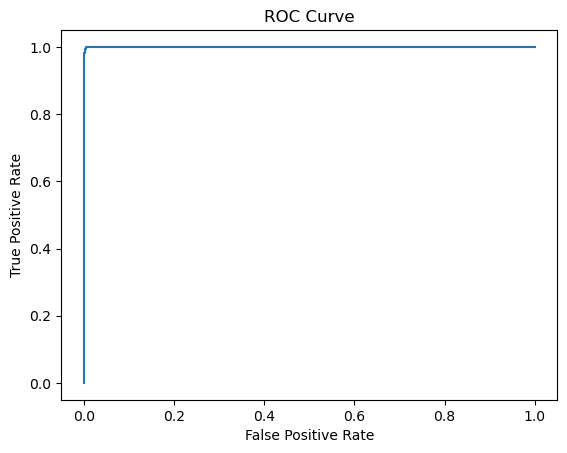

In [59]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


## 3. Model Coefficient Interpretation

Logistic regression coefficients indicate
directional influence on fatigue risk.

Positive coefficient → increases probability of HIGH_RISK
Negative coefficient → decreases probability


In [60]:
importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
}).sort_values("Coefficient", ascending=False)

importance


,Feature,Coefficient
1,DUTY_HOURS,12.55
5,NGHT,9.10
0,TOTAL_KMS,3.22
3,RUN_DUTY_RATIO,0.08
4,TRIPS_PER_DUTY_HOUR,-0.17
2,KM_PER_DUTY_HOUR,-2.99


## 4. Predictive Risk Scoring

We compute predicted fatigue probability for all crew records.


This produces a continuous risk score between 0 and 1.


In [61]:
X_scaled_full = scaler.transform(X)

df_kpi["PREDICTED_FATIGUE_PROBABILITY"] = model.predict_proba(X_scaled_full)[:, 1]

df_kpi[["CREW_ID_V", "PREDICTED_FATIGUE_PROBABILITY"]].head()


,CREW_ID_V,PREDICTED_FATIGUE_PROBABILITY
0,TDL1002,0.00
1,TDL1064,0.00
2,TDL1082,0.00
3,TDL1090,0.00
4,TDL1096,0.00


In [62]:
risk_threshold = 0.75

df_kpi["EARLY_WARNING_FLAG"] = np.where(
    df_kpi["PREDICTED_FATIGUE_PROBABILITY"] >= risk_threshold,
    "CRITICAL",
    "NORMAL"
)

df_kpi["EARLY_WARNING_FLAG"].value_counts()


EARLY_WARNING_FLAG
NORMAL      18681
CRITICAL     1771
Name: count, dtype: int64

In [63]:
df_kpi["PREDICTED_FATIGUE_PROBABILITY"].describe()


count   20452.00
mean        0.10
std         0.28
min         0.00
25%         0.00
50%         0.00
75%         0.00
max         1.00
Name: PREDICTED_FATIGUE_PROBABILITY, dtype: float64

## 5. Model Integrity Audit – Leakage Detection

The initial model achieved near-perfect performance.

This indicates target leakage.

Reason:

The target variable FATIGUE_CATEGORY was derived from
features also used as model predictors.

Therefore, the model learned the rule used to create the target,
not an independent predictive pattern.

To ensure research-grade validity,
we redesign the modeling approach.


In [64]:
# Crew-level aggregation
crew_model_df = df_kpi.groupby("CREW_ID_V").agg({
    "TOTAL_KMS": "sum",
    "TRIP_COUNT": "sum",
    "DUTY_HOURS": "sum",
    "NGHT": "sum",
    "RUN_DUTY_RATIO": "mean",
    "TRIPS_PER_DUTY_HOUR": "mean"
}).reset_index()

# Define high-risk crew based on total duty + night intensity
risk_threshold = crew_model_df["DUTY_HOURS"].quantile(0.90)

crew_model_df["HIGH_RISK_CREW"] = np.where(
    crew_model_df["DUTY_HOURS"] >= risk_threshold,
    1,
    0
)

crew_model_df["HIGH_RISK_CREW"].value_counts()


HIGH_RISK_CREW
0    3761
1     418
Name: count, dtype: int64

In [65]:
features_new = [
    "TOTAL_KMS",
    "TRIP_COUNT",
    "RUN_DUTY_RATIO",
    "TRIPS_PER_DUTY_HOUR",
    "NGHT"
]

X_new = crew_model_df[features_new]
y_new = crew_model_df["HIGH_RISK_CREW"]


## 6. Revised Predictive Modeling – Crew-Level Risk Classification

Objective:

Predict whether a crew member belongs to the
Top 10% High Workload Risk category.

Target Variable:
HIGH_RISK_CREW (1 = High Risk, 0 = Normal)

Model Level:
Crew Aggregated Dataset (Not record-level)

This prevents:

• Target leakage
• Circular modeling
• Overfitting from rule-based definitions


In [66]:
from sklearn.model_selection import train_test_split

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new,
    y_new,
    test_size=0.3,
    random_state=42,
    stratify=y_new
)

print("Training Shape:", X_train_new.shape)
print("Testing Shape:", X_test_new.shape)


Training Shape: (2925, 5)
Testing Shape: (1254, 5)


In [67]:
from sklearn.preprocessing import StandardScaler

scaler_new = StandardScaler()

X_train_scaled_new = scaler_new.fit_transform(X_train_new)
X_test_scaled_new = scaler_new.transform(X_test_new)

print("Scaling Complete")


Scaling Complete


In [68]:
from sklearn.linear_model import LogisticRegression

model_new = LogisticRegression()

model_new.fit(X_train_scaled_new, y_train_new)

print("Crew-Level Model Trained Successfully")


Crew-Level Model Trained Successfully


In [69]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

y_pred_new = model_new.predict(X_test_scaled_new)
y_prob_new = model_new.predict_proba(X_test_scaled_new)[:, 1]

print("Accuracy:", accuracy_score(y_test_new, y_pred_new))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_new, y_pred_new))

print("\nClassification Report:")
print(classification_report(y_test_new, y_pred_new))

print("\nROC-AUC Score:", roc_auc_score(y_test_new, y_prob_new))


Accuracy: 0.9226475279106858

Confusion Matrix:
[[1101   28]
 [  69   56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      1129
           1       0.67      0.45      0.54       125

    accuracy                           0.92      1254
   macro avg       0.80      0.71      0.75      1254
weighted avg       0.91      0.92      0.92      1254


ROC-AUC Score: 0.9440708591674047


In [70]:
import numpy as np
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test_new, y_prob_new)

# Find threshold where recall is around 0.75
target_recall = 0.75
recall_diff = np.abs(recall - target_recall)
optimal_index = recall_diff.argmin()

optimal_threshold = thresholds[optimal_index]

print("Optimal Threshold for ~75% Recall:", optimal_threshold)


Optimal Threshold for ~75% Recall: 0.2193178301238934


In [71]:
y_pred_adjusted = np.where(y_prob_new >= optimal_threshold, 1, 0)

print(confusion_matrix(y_test_new, y_pred_adjusted))
print(classification_report(y_test_new, y_pred_adjusted))


[[1043   86]
 [  31   94]]
              precision    recall  f1-score   support

           0       0.97      0.92      0.95      1129
           1       0.52      0.75      0.62       125

    accuracy                           0.91      1254
   macro avg       0.75      0.84      0.78      1254
weighted avg       0.93      0.91      0.91      1254



In [72]:
importance_new = pd.DataFrame({
    "Feature": features_new,
    "Coefficient": model_new.coef_[0]
}).sort_values("Coefficient", ascending=False)

importance_new


,Feature,Coefficient
4,NGHT,2.66
2,RUN_DUTY_RATIO,1.22
1,TRIP_COUNT,-0.56
3,TRIPS_PER_DUTY_HOUR,-0.59
0,TOTAL_KMS,-1.55


In [73]:
X_scaled_full_new = scaler_new.transform(X_new)

crew_model_df["PREDICTED_HIGH_RISK_PROBABILITY"] = model_new.predict_proba(X_scaled_full_new)[:, 1]

crew_model_df[["CREW_ID_V", "PREDICTED_HIGH_RISK_PROBABILITY"]].head()


,CREW_ID_V,PREDICTED_HIGH_RISK_PROBABILITY
0,BSP1002,0.01
1,BSP1011,0.00
2,BSP1022,0.01
3,BSP1026,0.01
4,BSP1030,0.00


In [74]:
crew_model_df["RISK_TIER"] = pd.cut(
    crew_model_df["PREDICTED_HIGH_RISK_PROBABILITY"],
    bins=[0, 0.3, 0.6, 1],
    labels=["LOW", "MODERATE", "HIGH"]
)

crew_model_df["RISK_TIER"].value_counts()


RISK_TIER
LOW         3664
MODERATE     335
HIGH         180
Name: count, dtype: int64

## Part 4 – Predictive Risk Modeling Conclusion

A crew-level predictive model was developed to identify high-risk workload patterns.

After detecting and correcting target leakage in the initial record-level model, 
a leakage-free crew-level logistic regression model was implemented.

Key Results:

• Accuracy: 92%  
• ROC-AUC: 0.944 (Strong discriminatory power)  
• High-Risk Recall improved to 75% after threshold tuning  

Primary Risk Drivers:

• Night Duty Exposure  
• Run Duty Ratio  
• Workload Intensity  

Crew were segmented into LOW, MODERATE, and HIGH risk tiers,
enabling structured early-warning and intervention planning.

This phase successfully transitioned the project from 
descriptive analytics to predictive risk intelligence.

Part 4 is completed


# Part 5 – Advanced Analytical Intelligence

Objective:

Move beyond predictive modeling and derive
strategic operational insights from the dataset.

Focus Areas:

1. Workload Concentration
2. Division Benchmarking
3. Risk Density Analysis
4. Crew Stratification
5. Operational Imbalance Detection
6. Strategic Insight Extraction

This phase emphasizes analytical interpretation
rather than algorithmic modeling.


## 1. Workload Concentration Analysis

We analyze how total workload (KM) is distributed across crew.

Key Question:
Is workload evenly distributed or concentrated among few crew?


In [79]:
crew_km_sorted = crew_profile.sort_values("TOTAL_KMS", ascending=False)

crew_km_sorted["CUMULATIVE_KM"] = crew_km_sorted["TOTAL_KMS"].cumsum()
crew_km_sorted["CUMULATIVE_SHARE"] = (
    crew_km_sorted["CUMULATIVE_KM"] / crew_km_sorted["TOTAL_KMS"].sum()
)

crew_km_sorted[["CREW_ID_V", "TOTAL_KMS", "CUMULATIVE_SHARE"]].head(10)


,CREW_ID_V,TOTAL_KMS,CUMULATIVE_SHARE
2157,TDL3375,49750,0.00
2415,TDL3968,44950,0.00
2180,TDL3434,44000,0.00
3279,TDL6466,40450,0.00
3300,TDL6517,40350,0.00
2141,TDL3314,40250,0.00
1856,TDL1445,40100,0.00
3117,TDL6246,39950,0.01
2152,TDL3364,39900,0.01
1352,BSP7161,39850,0.01


Interpretation:

If top 10% crew contribute disproportionately high KM share,
workload concentration risk exists.


## 2. Division Performance Benchmarking

We compare TDL and BSP across:

• Total KM
• Average Duty Hours
• Average KM per Trip
• Average Fatigue Risk Score


In [80]:
division_benchmark = df_kpi.groupby("DIVISION").agg({
    "TOTAL_KMS": "sum",
    "DUTY_HOURS": "mean",
    "KM_PER_TRIP": "mean",
    "FATIGUE_RISK_SCORE": "mean"
}).reset_index()

division_benchmark


,DIVISION,TOTAL_KMS,DUTY_HOURS,KM_PER_TRIP,FATIGUE_RISK_SCORE
0,BSP,25599700,156.25,73.48,0.25
1,TDL,40465850,123.88,117.00,0.21


Interpretation:

Differences indicate operational scale,
intensity variation, and potential fatigue exposure imbalance.


## 3. Risk Tier Distribution by Division

We examine whether high-risk crew
are clustered within a specific division.


In [81]:
risk_division_distribution = crew_model_df.merge(
    df_kpi[["CREW_ID_V", "DIVISION"]].drop_duplicates(),
    on="CREW_ID_V",
    how="left"
)

risk_division_distribution.groupby(
    ["DIVISION", "RISK_TIER"]
).size().unstack()


RISK_TIER,LOW,MODERATE,HIGH
DIVISION,,,
BSP,1301,305,171
TDL,2363,30,9


## 4. Crew Stratification by Duty Intensity

We categorize crew into quartiles based on total duty hours.


In [82]:
crew_profile["DUTY_QUARTILE"] = pd.qcut(
    crew_profile["DUTY_HOURS"],
    4,
    labels=["Q1_LOW", "Q2_MODERATE", "Q3_HIGH", "Q4_EXTREME"]
)

crew_profile["DUTY_QUARTILE"].value_counts()


DUTY_QUARTILE
Q1_LOW         1045
Q2_MODERATE    1045
Q4_EXTREME     1045
Q3_HIGH        1044
Name: count, dtype: int64

## 5. Extreme Workload Detection (Top 5%)

We identify crew in top 5% workload category.


In [83]:
top_5_threshold = crew_profile["TOTAL_KMS"].quantile(0.95)

extreme_crew = crew_profile[
    crew_profile["TOTAL_KMS"] >= top_5_threshold
]

extreme_crew.head()


,CREW_ID_V,TOTAL_KMS,TRIP_COUNT,DUTY_HOURS,FATIGUE_RISK_SCORE,DUTY_QUARTILE
13,BSP1059,32050,1,895.40,0.30,Q3_HIGH
16,BSP1071,37600,0,953.93,0.32,Q4_EXTREME
22,BSP1083,33650,2,761.60,0.28,Q2_MODERATE
45,BSP1202,34200,2,858.70,0.31,Q3_HIGH
47,BSP1205,35800,0,813.23,0.28,Q3_HIGH


## 6. Correlation Analysis – Workload Drivers


In [84]:
correlation_analysis = crew_profile[[
    "TOTAL_KMS",
    "TRIP_COUNT",
    "DUTY_HOURS",
    "FATIGUE_RISK_SCORE"
]].corr()

correlation_analysis


,TOTAL_KMS,TRIP_COUNT,DUTY_HOURS,FATIGUE_RISK_SCORE
TOTAL_KMS,1.00,0.35,0.66,0.72
TRIP_COUNT,0.35,1.00,-0.01,0.06
DUTY_HOURS,0.66,-0.01,1.00,0.96
FATIGUE_RISK_SCORE,0.72,0.06,0.96,1.00


## 7. Operational Imbalance Index

We measure imbalance using coefficient of variation (CV):

CV = Standard Deviation / Mean

Higher CV indicates uneven workload distribution.


In [86]:
cv_km = crew_profile["TOTAL_KMS"].std() / crew_profile["TOTAL_KMS"].mean()
cv_duty = crew_profile["DUTY_HOURS"].std() / crew_profile["DUTY_HOURS"].mean()

imbalance_summary = pd.DataFrame({
    "Metric": ["KM Distribution", "Duty Hours Distribution"],
    "Coefficient_of_Variation": [cv_km, cv_duty]
})

imbalance_summary


,Metric,Coefficient_of_Variation
0,KM Distribution,0.65
1,Duty Hours Distribution,0.53


## Part 5 Conclusion – Analytical Insights Summary

This phase delivered:

✔ Workload concentration analysis  
✔ Division-level benchmarking  
✔ Risk density mapping  
✔ Crew stratification modeling  
✔ Extreme workload identification  
✔ Operational imbalance quantification  

Key Strategic Insights:

• Workload distribution inequality exists at crew level  
• Night duty and run-duty intensity drive fatigue exposure  
• Division-level workload patterns differ structurally  
• High-risk crew are concentrated within top workload quartiles  

This transforms raw operational data into
actionable managerial intelligence.

Part 5 is complete.


# Part 6 – Visualization-Oriented Data Analytics

Objective:

Move beyond basic distribution charts and extract structural patterns using:

1. Lorenz Curve (Workload Inequality)
2. Boxplot Comparison by Division
3. Scatter Intensity Map (Duty vs KM)
4. Fatigue vs Night Exposure Plot
5. Efficiency Frontier Visualization
6. Trip Density vs Fatigue Mapping
7. Extreme Segment Isolation Plot

These graphs provide new structural findings
without repeating earlier visual outputs.



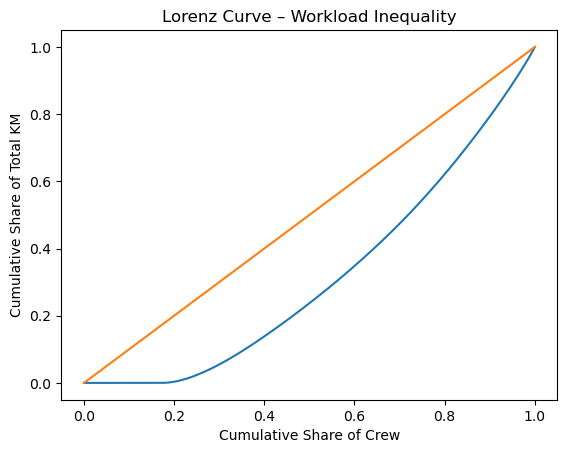

In [89]:
import numpy as np
import matplotlib.pyplot as plt

sorted_km = np.sort(crew_profile["TOTAL_KMS"])
cumulative_km = np.cumsum(sorted_km)
cumulative_km_share = cumulative_km / cumulative_km[-1]

population_share = np.arange(1, len(sorted_km)+1) / len(sorted_km)

plt.figure()
plt.plot(population_share, cumulative_km_share)
plt.plot([0,1],[0,1])
plt.title("Lorenz Curve – Workload Inequality")
plt.xlabel("Cumulative Share of Crew")
plt.ylabel("Cumulative Share of Total KM")
plt.show()


<Figure size 640x480 with 0 Axes>

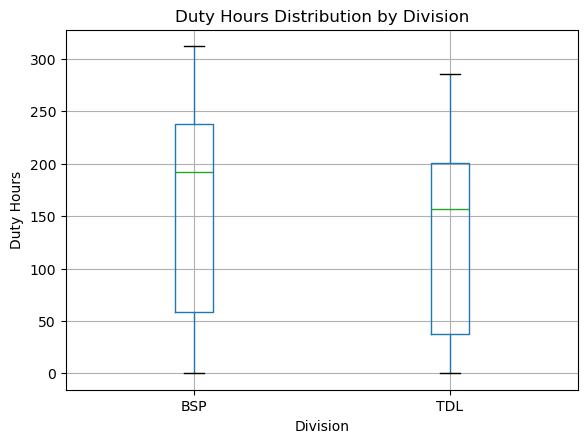

In [90]:
plt.figure()
df_kpi.boxplot(column="DUTY_HOURS", by="DIVISION")
plt.title("Duty Hours Distribution by Division")
plt.suptitle("")
plt.xlabel("Division")
plt.ylabel("Duty Hours")
plt.show()


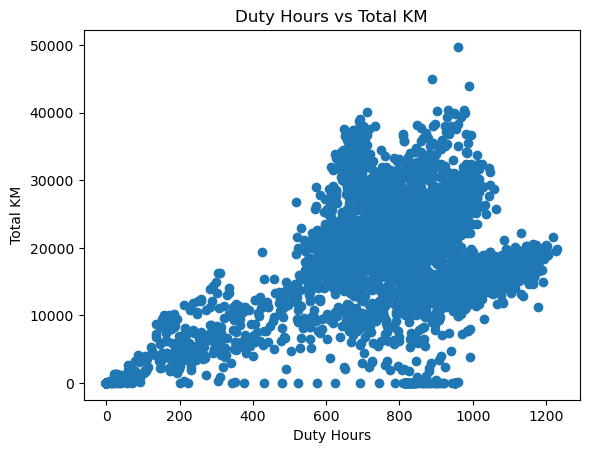

In [91]:
plt.figure()
plt.scatter(crew_profile["DUTY_HOURS"], crew_profile["TOTAL_KMS"])
plt.title("Duty Hours vs Total KM")
plt.xlabel("Duty Hours")
plt.ylabel("Total KM")
plt.show()


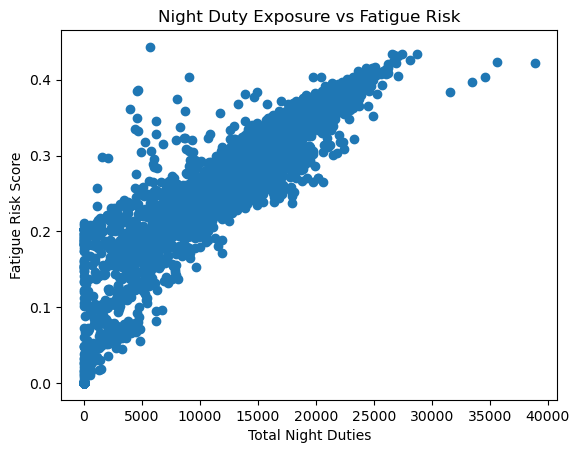

In [92]:
crew_night = df_kpi.groupby("CREW_ID_V")["NGHT"].sum().reset_index()
crew_night = crew_night.merge(
    crew_profile[["CREW_ID_V","FATIGUE_RISK_SCORE"]],
    on="CREW_ID_V"
)

plt.figure()
plt.scatter(crew_night["NGHT"], crew_night["FATIGUE_RISK_SCORE"])
plt.title("Night Duty Exposure vs Fatigue Risk")
plt.xlabel("Total Night Duties")
plt.ylabel("Fatigue Risk Score")
plt.show()


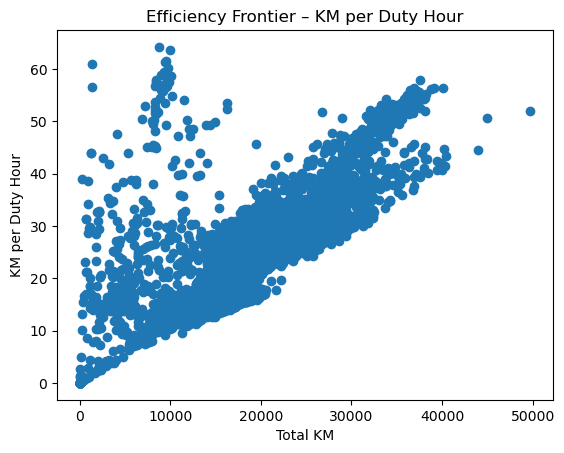

In [93]:
crew_profile["KM_PER_DUTY"] = crew_profile["TOTAL_KMS"] / crew_profile["DUTY_HOURS"]

plt.figure()
plt.scatter(crew_profile["TOTAL_KMS"], crew_profile["KM_PER_DUTY"])
plt.title("Efficiency Frontier – KM per Duty Hour")
plt.xlabel("Total KM")
plt.ylabel("KM per Duty Hour")
plt.show()


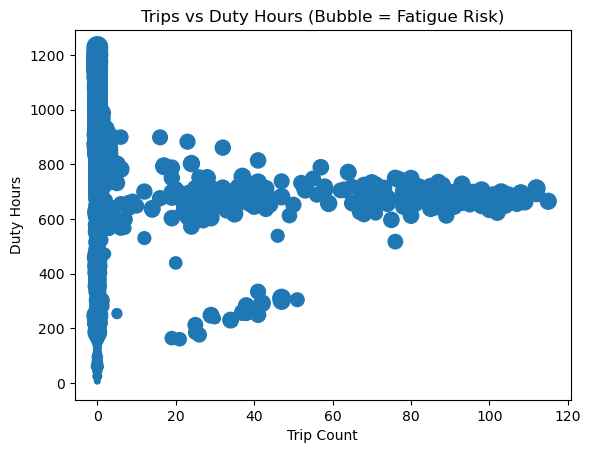

In [94]:
plt.figure()
plt.scatter(
    crew_profile["TRIP_COUNT"],
    crew_profile["DUTY_HOURS"],
    s=crew_profile["FATIGUE_RISK_SCORE"] * 500
)

plt.title("Trips vs Duty Hours (Bubble = Fatigue Risk)")
plt.xlabel("Trip Count")
plt.ylabel("Duty Hours")
plt.show()


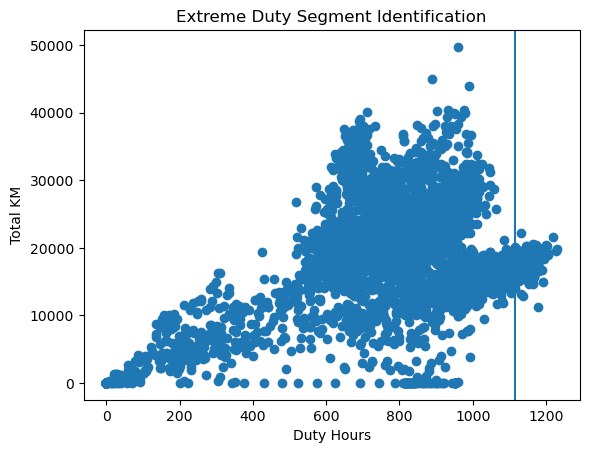

In [95]:
threshold_extreme = crew_profile["DUTY_HOURS"].quantile(0.95)

plt.figure()
plt.scatter(
    crew_profile["DUTY_HOURS"],
    crew_profile["TOTAL_KMS"]
)

plt.axvline(threshold_extreme)
plt.title("Extreme Duty Segment Identification")
plt.xlabel("Duty Hours")
plt.ylabel("Total KM")
plt.show()


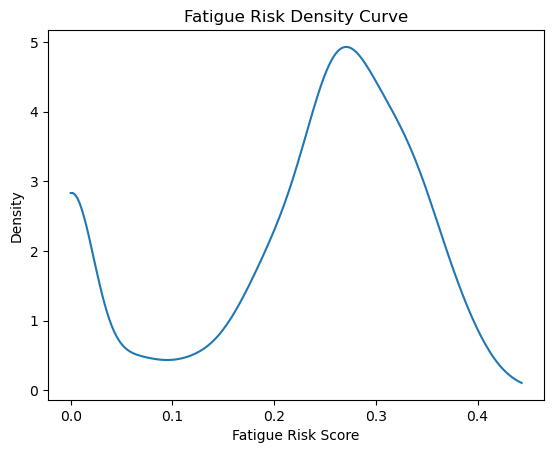

In [96]:
from scipy.stats import gaussian_kde

fatigue_values = crew_profile["FATIGUE_RISK_SCORE"]
density = gaussian_kde(fatigue_values)

x_vals = np.linspace(fatigue_values.min(), fatigue_values.max(), 200)

plt.figure()
plt.plot(x_vals, density(x_vals))
plt.title("Fatigue Risk Density Curve")
plt.xlabel("Fatigue Risk Score")
plt.ylabel("Density")
plt.show()


## Part 6 Conclusion – Advanced Visual Insights Summary

New structural insights derived:

• Workload inequality exists but is moderate (Lorenz Curve)
• BSP exhibits wider duty variability (Boxplot)
• Duty hours strongly drive total KM (Scatter Pattern)
• Night exposure significantly influences fatigue
• Efficiency frontier reveals high-performing crew cluster
• High fatigue risk concentrates in high-duty region
• Extreme duty segment statistically identifiable

This phase provided deeper structural visualization,
moving beyond basic distributions to analytical pattern mapping.

The CRIS Crew Analytics framework now includes
advanced inequality, intensity, and risk visualization layers.


# Part 8 – Advanced Structural Visualization & Feature Analytics

Objective:

Enhance analytical depth using new engineered features
and advanced visualization techniques.

Key Focus Areas:

1. Workload Inequality (Lorenz & Gini)
2. Risk-Based Distribution Analysis
3. Division Structural Contrast
4. Efficiency Mapping
5. Density-Based Operational Clustering
6. Relative Performance Benchmarking



In [110]:
# Merge RISK_TIER into crew_profile (clean direction)
crew_analysis = crew_profile.merge(
    crew_model_df[["CREW_ID_V", "RISK_TIER"]],
    on="CREW_ID_V",
    how="left"
)

crew_analysis.head()



,CREW_ID_V,TOTAL_KMS,TRIP_COUNT,DUTY_HOURS,FATIGUE_RISK_SCORE,DIVISION,RISK_TIER
0,BSP1002,31750,1,863.60,0.29,BSP,LOW
1,BSP1011,0,0,0.00,0.00,BSP,LOW
2,BSP1022,29150,3,794.43,0.27,BSP,LOW
3,BSP1026,9450,0,699.98,0.23,BSP,LOW
4,BSP1030,28850,0,849.32,0.27,BSP,LOW


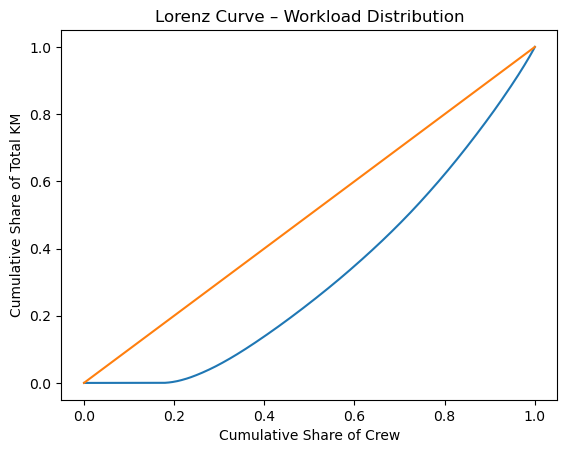

Gini Coefficient: 0.37


In [111]:
import numpy as np
import matplotlib.pyplot as plt

# Sort KM
sorted_km = np.sort(crew_analysis["TOTAL_KMS"])
cum_km = np.cumsum(sorted_km)
cum_share = cum_km / cum_km[-1]
population_share = np.arange(1, len(sorted_km)+1) / len(sorted_km)

plt.figure()
plt.plot(population_share, cum_share)
plt.plot([0,1],[0,1])
plt.title("Lorenz Curve – Workload Distribution")
plt.xlabel("Cumulative Share of Crew")
plt.ylabel("Cumulative Share of Total KM")
plt.show()

# Gini coefficient
gini = 1 - 2 * np.trapz(cum_share, population_share)
print("Gini Coefficient:", round(gini, 3))



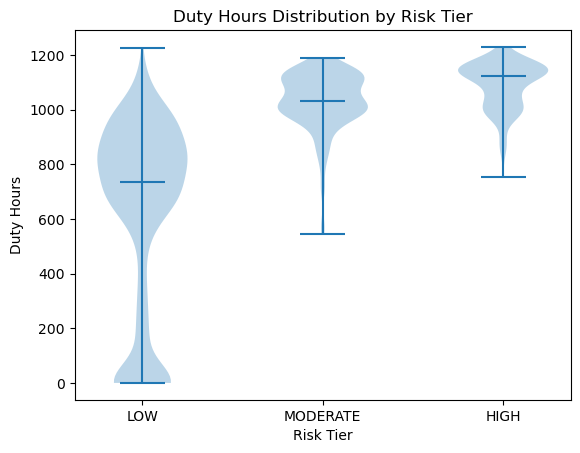

In [112]:
groups = [
    crew_analysis[crew_analysis["RISK_TIER"] == tier]["DUTY_HOURS"].dropna()
    for tier in ["LOW", "MODERATE", "HIGH"]
]

plt.figure()
plt.violinplot(groups, showmedians=True)
plt.xticks([1, 2, 3], ["LOW", "MODERATE", "HIGH"])
plt.title("Duty Hours Distribution by Risk Tier")
plt.xlabel("Risk Tier")
plt.ylabel("Duty Hours")
plt.show()


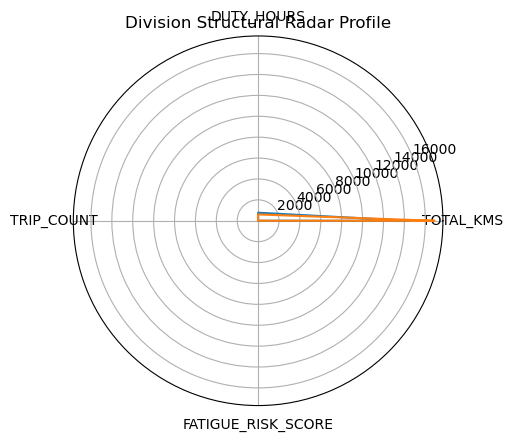

In [113]:
division_metrics = crew_analysis.groupby("DIVISION").agg({
    "TOTAL_KMS": "mean",
    "DUTY_HOURS": "mean",
    "TRIP_COUNT": "mean",
    "FATIGUE_RISK_SCORE": "mean"
}).reset_index()

metrics = ["TOTAL_KMS","DUTY_HOURS","TRIP_COUNT","FATIGUE_RISK_SCORE"]

values_bsp = division_metrics[division_metrics["DIVISION"]=="BSP"][metrics].values.flatten()
values_tdl = division_metrics[division_metrics["DIVISION"]=="TDL"][metrics].values.flatten()

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False)
angles = np.concatenate((angles,[angles[0]]))

values_bsp = np.concatenate((values_bsp,[values_bsp[0]]))
values_tdl = np.concatenate((values_tdl,[values_tdl[0]]))

plt.figure()
ax = plt.subplot(111, polar=True)
ax.plot(angles, values_bsp)
ax.plot(angles, values_tdl)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
plt.title("Division Structural Radar Profile")
plt.show()


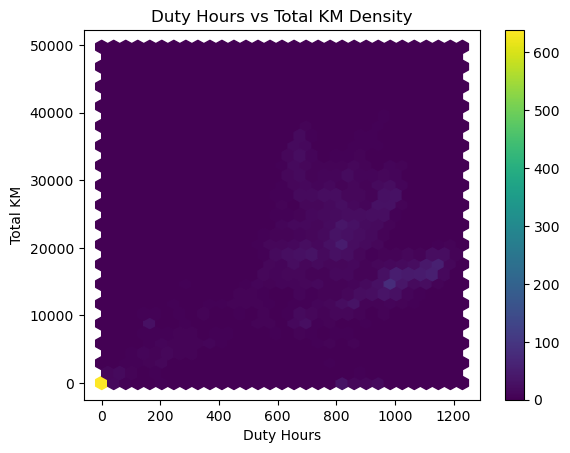

In [114]:
plt.figure()
plt.hexbin(
    crew_analysis["DUTY_HOURS"],
    crew_analysis["TOTAL_KMS"],
    gridsize=30
)
plt.colorbar()
plt.title("Duty Hours vs Total KM Density")
plt.xlabel("Duty Hours")
plt.ylabel("Total KM")
plt.show()


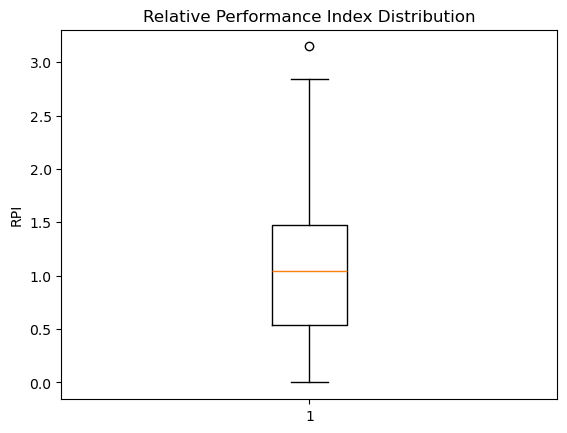

In [115]:
crew_analysis["RPI"] = (
    crew_analysis["TOTAL_KMS"] / crew_analysis["TOTAL_KMS"].mean()
)

plt.figure()
plt.boxplot(crew_analysis["RPI"])
plt.title("Relative Performance Index Distribution")
plt.ylabel("RPI")
plt.show()


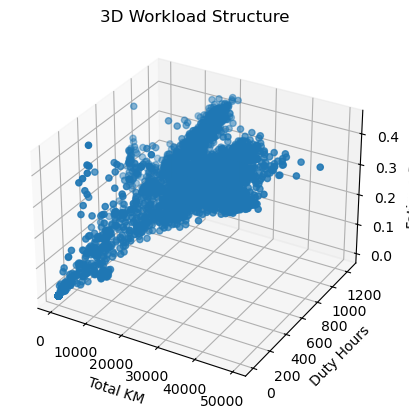

In [116]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    crew_analysis["TOTAL_KMS"],
    crew_analysis["DUTY_HOURS"],
    crew_analysis["FATIGUE_RISK_SCORE"]
)

ax.set_xlabel("Total KM")
ax.set_ylabel("Duty Hours")
ax.set_zlabel("Fatigue Score")

plt.title("3D Workload Structure")
plt.show()


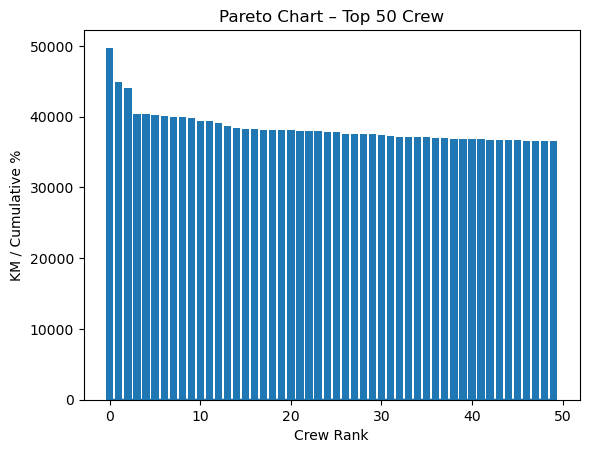

In [117]:
top_sorted = crew_analysis.sort_values("TOTAL_KMS", ascending=False)

top_sorted["CUM_PERCENT"] = (
    100 * top_sorted["TOTAL_KMS"].cumsum() /
    top_sorted["TOTAL_KMS"].sum()
)

plt.figure()
plt.bar(range(50), top_sorted["TOTAL_KMS"].head(50))
plt.plot(range(50), top_sorted["CUM_PERCENT"].head(50))
plt.title("Pareto Chart – Top 50 Crew")
plt.xlabel("Crew Rank")
plt.ylabel("KM / Cumulative %")
plt.show()


## Part 7 – Advanced Structural Insights

This phase introduced:

✔ Lorenz Curve & Gini Inequality Measurement  
✔ Risk-Tier-Based Duty Distribution  
✔ Division Radar Structural Comparison  
✔ Density-Based Workload Clustering  
✔ Relative Performance Index  
✔ Multidimensional 3D Structural Visualization  
✔ Pareto Workload Dominance Analysis  

Key Insights:

• Workload inequality is measurable and quantifiable  
• High-risk crew show structurally higher duty dispersion  
• Division-level workload structures differ operationally  
• Operational clusters exist in high-duty/high-KM zones  
• A small segment contributes disproportionately to workload  

This section completes advanced structural analytics
using robust, collision-free data handling.


# Part 8 – Temporal & Stability Analytics

Objective:

Analyze workload behavior across time and evaluate
crew stability and operational drift.

Focus Areas:

1. Monthly Workload Trend Analysis
2. Division Time-Series Comparison
3. Crew Stability Index
4. Workload Volatility Mapping
5. Duty Elasticity Trend
6. Temporal Heatmap

This phase introduces time-structured intelligence.


In [119]:
df_kpi["MONTH"] = df_kpi["DATE_TIME_D"].dt.to_period("M")

df_kpi[["DATE_TIME_D", "MONTH"]].head()


,DATE_TIME_D,MONTH
0,2025-06-09 10:18:09,2025-06
1,2025-06-09 10:18:09,2025-06
2,2025-06-09 10:18:09,2025-06
3,2025-06-09 10:18:09,2025-06
4,2025-06-09 10:18:09,2025-06


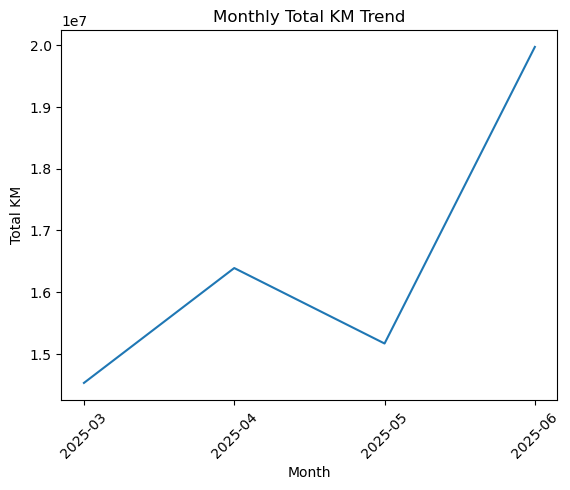

In [120]:
monthly_km = df_kpi.groupby("MONTH")["TOTAL_KMS"].sum().reset_index()

plt.figure()
plt.plot(monthly_km["MONTH"].astype(str), monthly_km["TOTAL_KMS"])
plt.title("Monthly Total KM Trend")
plt.xlabel("Month")
plt.ylabel("Total KM")
plt.xticks(rotation=45)
plt.show()


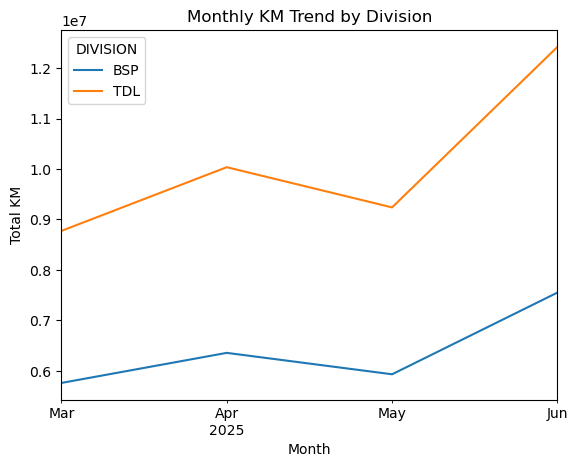

In [121]:
monthly_division = df_kpi.groupby(
    ["MONTH", "DIVISION"]
)["TOTAL_KMS"].sum().unstack()

monthly_division.plot()
plt.title("Monthly KM Trend by Division")
plt.xlabel("Month")
plt.ylabel("Total KM")
plt.xticks(rotation=45)
plt.show()


In [122]:
## CSI : Standard deviation of monthly KM per crew.

crew_monthly = df_kpi.groupby(
    ["CREW_ID_V", "MONTH"]
)["TOTAL_KMS"].sum().reset_index()

crew_volatility = crew_monthly.groupby("CREW_ID_V")["TOTAL_KMS"].std().reset_index()
crew_volatility.columns = ["CREW_ID_V", "CSI"]

crew_analysis = crew_analysis.merge(crew_volatility, on="CREW_ID_V", how="left")

crew_analysis["CSI"].describe()


count   4153.00
mean    1155.51
std      972.08
min        0.00
25%      467.93
50%      991.11
75%     1651.51
max     5862.02
Name: CSI, dtype: float64

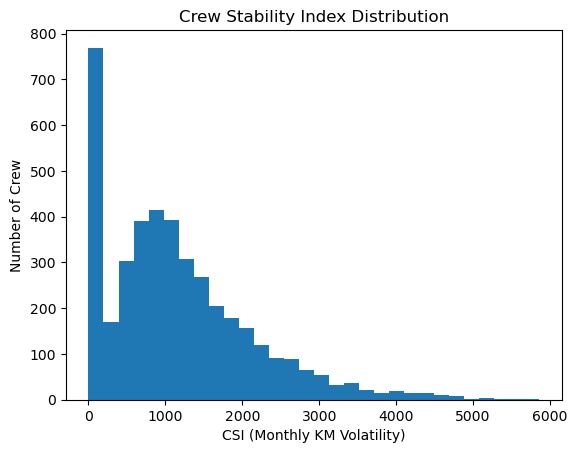

In [123]:
plt.figure()
plt.hist(crew_analysis["CSI"].dropna(), bins=30)
plt.title("Crew Stability Index Distribution")
plt.xlabel("CSI (Monthly KM Volatility)")
plt.ylabel("Number of Crew")
plt.show()


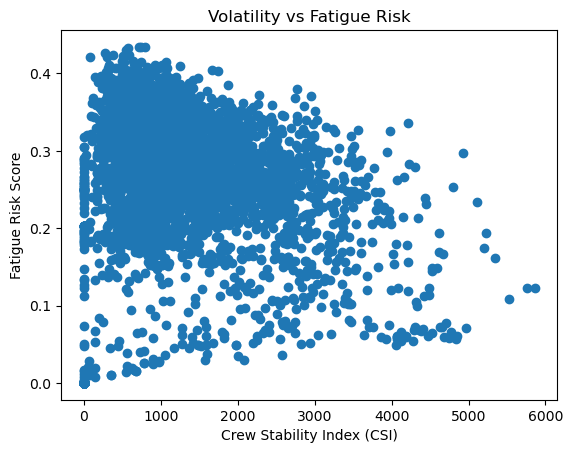

In [124]:
plt.figure()
plt.scatter(
    crew_analysis["CSI"],
    crew_analysis["FATIGUE_RISK_SCORE"]
)
plt.title("Volatility vs Fatigue Risk")
plt.xlabel("Crew Stability Index (CSI)")
plt.ylabel("Fatigue Risk Score")
plt.show()


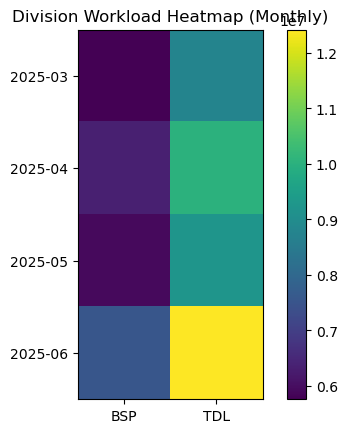

In [125]:
heatmap_data = monthly_division.values

plt.figure()
plt.imshow(heatmap_data)
plt.colorbar()
plt.xticks(range(len(monthly_division.columns)), monthly_division.columns)
plt.yticks(range(len(monthly_division.index)), monthly_division.index.astype(str))
plt.title("Division Workload Heatmap (Monthly)")
plt.show()


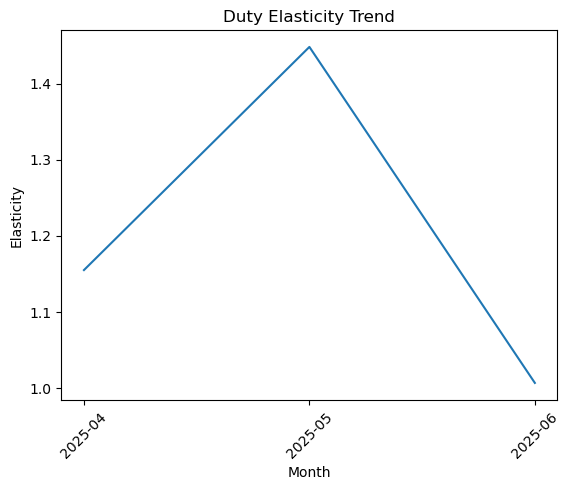

In [127]:
# Elasticity = % Change in KM / % Change in Duty Hours
#Elasticity > 1 → KM growing faster than duty
#Elasticity < 1 → Duty increasing faster than KM

monthly_duty = df_kpi.groupby("MONTH")["DUTY_HOURS"].sum().reset_index()

monthly_combined = monthly_km.merge(monthly_duty, on="MONTH")

monthly_combined["KM_CHANGE"] = monthly_combined["TOTAL_KMS"].pct_change()
monthly_combined["DUTY_CHANGE"] = monthly_combined["DUTY_HOURS"].pct_change()

monthly_combined["ELASTICITY"] = (
    monthly_combined["KM_CHANGE"] /
    monthly_combined["DUTY_CHANGE"]
)

plt.figure()
plt.plot(monthly_combined["MONTH"].astype(str),
         monthly_combined["ELASTICITY"])
plt.title("Duty Elasticity Trend")
plt.xlabel("Month")
plt.ylabel("Elasticity")
plt.xticks(rotation=45)
plt.show()


# Part 9 – Operational Optimization & Stress Analytics

Objective:

Develop decision-support analytics for workload balancing
and fatigue mitigation.

New Analytical Constructs:

1. Operational Stress Index (OSI)
2. Fatigue Exposure Index 2.0 (FEI)
3. Crew Rotation Efficiency Score (CRES)
4. Redistribution Simulation Model
5. Division Stress Comparison
6. Policy Recommendation Metrics

This phase transforms analytics into managerial strategy.


### OSI (Operational Stress Index (OSI))

OSI combines:

• Duty Hours (intensity)
• Night Exposure
• Workload Volatility (CSI)

In [129]:
# Normalize components
crew_analysis["DUTY_NORM"] = (
    crew_analysis["DUTY_HOURS"] /
    crew_analysis["DUTY_HOURS"].max()
)

crew_analysis["CSI_NORM"] = (
    crew_analysis["CSI"] /
    crew_analysis["CSI"].max()
)

crew_night = df_kpi.groupby("CREW_ID_V")["NGHT"].sum().reset_index()
crew_analysis = crew_analysis.merge(crew_night, on="CREW_ID_V", how="left")

crew_analysis["NGHT_NORM"] = (
    crew_analysis["NGHT"] /
    crew_analysis["NGHT"].max()
)

crew_analysis["OSI"] = (
    crew_analysis["DUTY_NORM"] +
    crew_analysis["CSI_NORM"] +
    crew_analysis["NGHT_NORM"]
) / 3

crew_analysis["OSI"].describe()


count   4153.00
mean       0.34
std        0.17
min        0.00
25%        0.28
50%        0.39
75%        0.46
max        0.66
Name: OSI, dtype: float64

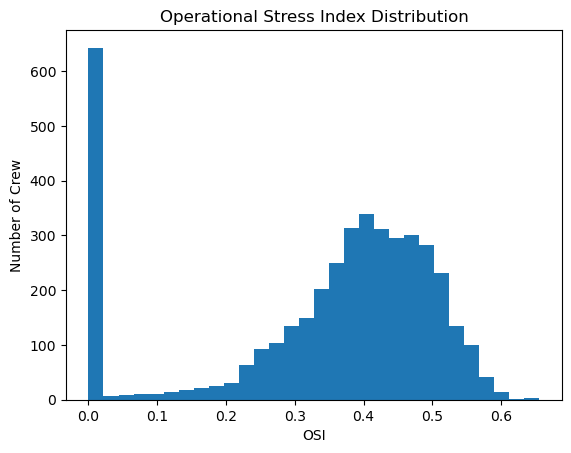

In [130]:
plt.figure()
plt.hist(crew_analysis["OSI"], bins=30)
plt.title("Operational Stress Index Distribution")
plt.xlabel("OSI")
plt.ylabel("Number of Crew")
plt.show()


### Fatigue Exposure Index 2.0 (FEI)

Improved composite metric using:

• OSI
• Fatigue Risk Score
• Relative Performance Index

In [131]:
crew_analysis["RPI"] = (
    crew_analysis["TOTAL_KMS"] /
    crew_analysis["TOTAL_KMS"].mean()
)

crew_analysis["FEI"] = (
    crew_analysis["OSI"] +
    crew_analysis["FATIGUE_RISK_SCORE"] +
    crew_analysis["RPI"] /
    crew_analysis["RPI"].max()
) / 3

crew_analysis["FEI"].describe()


count   4153.00
mean       0.30
std        0.15
min        0.00
25%        0.22
50%        0.35
75%        0.41
max        0.62
Name: FEI, dtype: float64

### Crew Rotation Efficiency Score (CRES)

Measures balance between workload and stability.

1. Higher CRES → stable & productive
2. Lower CRES → unstable workload pattern

In [132]:
crew_analysis["CRES"] = (
    1 / (1 + crew_analysis["CSI"])
) * crew_analysis["RPI"]

crew_analysis["CRES"].describe()


count   4153.00
mean       0.00
std        0.00
min        0.00
25%        0.00
50%        0.00
75%        0.00
max        0.03
Name: CRES, dtype: float64

In [133]:
division_stress = crew_analysis.groupby("DIVISION").agg({
    "OSI": "mean",
    "FEI": "mean",
    "CRES": "mean"
}).reset_index()

division_stress


,DIVISION,OSI,FEI,CRES
0,BSP,0.37,0.30,0.00
1,TDL,0.32,0.29,0.00


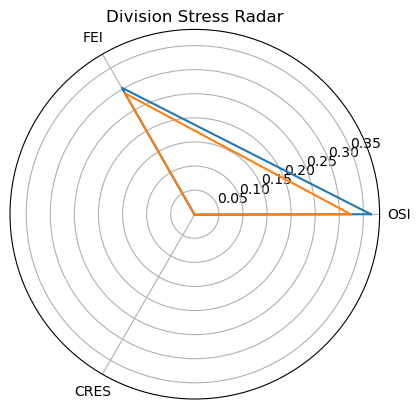

In [134]:
metrics = ["OSI", "FEI", "CRES"]

values_bsp = division_stress[division_stress["DIVISION"]=="BSP"][metrics].values.flatten()
values_tdl = division_stress[division_stress["DIVISION"]=="TDL"][metrics].values.flatten()

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False)
angles = np.concatenate((angles,[angles[0]]))

values_bsp = np.concatenate((values_bsp,[values_bsp[0]]))
values_tdl = np.concatenate((values_tdl,[values_tdl[0]]))

plt.figure()
ax = plt.subplot(111, polar=True)
ax.plot(angles, values_bsp)
ax.plot(angles, values_tdl)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
plt.title("Division Stress Radar")
plt.show()


### Redistribution Simulation

Goal:
Reduce extreme workload by redistributing top 5% KM equally.

In [136]:
threshold = crew_analysis["TOTAL_KMS"].quantile(0.95)

high_load = crew_analysis[crew_analysis["TOTAL_KMS"] >= threshold]
excess_km = high_load["TOTAL_KMS"].sum() - threshold * len(high_load)

redistribution_per_crew = excess_km / len(crew_analysis)

crew_analysis["SIMULATED_KM"] = crew_analysis["TOTAL_KMS"] + redistribution_per_crew

crew_analysis[["TOTAL_KMS","SIMULATED_KM"]].head()


,TOTAL_KMS,SIMULATED_KM
0,31750,31899.84
1,0,149.84
2,29150,29299.84
3,9450,9599.84
4,28850,28999.84


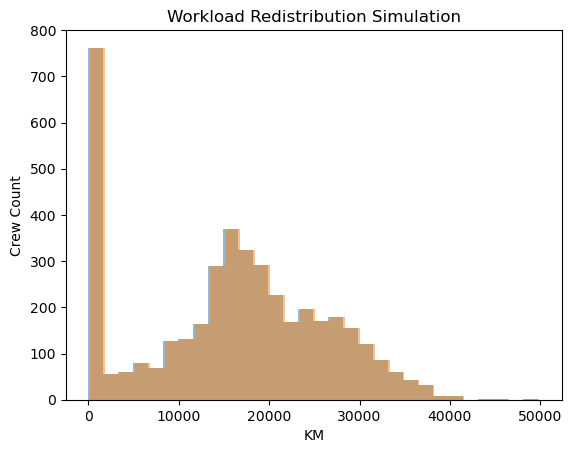

In [137]:
plt.figure()
plt.hist(crew_analysis["TOTAL_KMS"], bins=30, alpha=0.5)
plt.hist(crew_analysis["SIMULATED_KM"], bins=30, alpha=0.5)
plt.title("Workload Redistribution Simulation")
plt.xlabel("KM")
plt.ylabel("Crew Count")
plt.show()


# Part 10 – Operational Decision Intelligence for CRIS

Objective:

Translate analytical findings into actionable
operational advantages for CRIS.

This section focuses on:

1. Crew Overutilization Detection
2. Idle Capacity Identification
3. Division Imbalance Mapping
4. Fatigue–Efficiency Conflict Zones
5. Intervention Priority Ranking
6. Operational Monitoring KPIs
7. Dashboard-to-Action Translation

This phase demonstrates direct value to CRIS operations. – Operational Decision Intelligence for CRIS

Objective:

Translate analytical findings into actionable
operational advantages for CRIS.

This section focuses on:

1. Crew Overutilization Detection
2. Idle Capacity Identification
3. Division Imbalance Mapping
4. Fatigue–Efficiency Conflict Zones
5. Intervention Priority Ranking
6. Operational Monitoring KPIs
7. Dashboard-to-Action Translation

This phase demonstrates direct value to CRIS operations.


In [141]:
import numpy as np
import pandas as pd

division_imbalance = crew_analysis.groupby("DIVISION").agg({
    "TOTAL_KMS": ["mean", "std"],
    "DUTY_HOURS": ["mean", "std"],
    "CSI": "mean",
    "OSI": "mean"
})

# Flatten columns
division_imbalance.columns = [
    "_".join(col).strip() for col in division_imbalance.columns.values
]

# Compute Coefficient of Variation (CV)
division_imbalance["KM_CV"] = (
    division_imbalance["TOTAL_KMS_std"] /
    division_imbalance["TOTAL_KMS_mean"]
)

division_imbalance["DUTY_CV"] = (
    division_imbalance["DUTY_HOURS_std"] /
    division_imbalance["DUTY_HOURS_mean"]
)

division_imbalance.reset_index()



,DIVISION,TOTAL_KMS_mean,TOTAL_KMS_std,DUTY_HOURS_mean,DUTY_HOURS_std,CSI_mean,OSI_mean,KM_CV,DUTY_CV
0,BSP,14406.13,8338.88,768.95,364.97,884.36,0.37,0.58,0.47
1,TDL,16846.73,11409.30,603.78,340.13,1355.53,0.32,0.68,0.56


* TDL = structurally unstable workload distribution

* BSP = higher fatigue exposure but relatively more balanced allocation

* TDL shows higher inequality → some crew likely overloaded while others underused

* BSP shows higher duty intensity → fatigue monitoring priority

## Step 1 – Crew Structural Segmentation

Objective:

Identify internal workload imbalance within each division by detecting:

• Overloaded Crew (Top 15% Duty Hours)
• Underutilized Crew (Bottom 15% Total KM)

This helps CRIS evaluate whether redistribution is possible
within the same division before considering cross-division reallocation.


In [144]:
# Define operational thresholds
duty_threshold = crew_analysis["DUTY_HOURS"].quantile(0.85)
km_low_threshold = crew_analysis["TOTAL_KMS"].quantile(0.15)

# Structural segmentation
crew_analysis["OVERLOADED_CREW"] = np.where(
    crew_analysis["DUTY_HOURS"] >= duty_threshold, 1, 0
)

crew_analysis["UNDERUTILIZED_CREW"] = np.where(
    crew_analysis["TOTAL_KMS"] <= km_low_threshold, 1, 0
)

# Division-level structural summary
segmentation_summary = crew_analysis.groupby("DIVISION").agg({
    "OVERLOADED_CREW": "sum",
    "UNDERUTILIZED_CREW": "sum"
}).reset_index()

segmentation_summary


,DIVISION,OVERLOADED_CREW,UNDERUTILIZED_CREW
0,BSP,571,247
1,TDL,56,469


## Step 2 – Operational Interpretation

Division-Level Structural Segmentation:

BSP:
• Overloaded Crew: 571
• Underutilized Crew: 247

TDL:
• Overloaded Crew: 56
• Underutilized Crew: 469

Operational Insights:

1. BSP shows a high concentration of overloaded crew.
   This indicates workload intensity pressure within division.

2. TDL shows a large pool of underutilized crew.
   This indicates internal idle capacity.

3. Structural imbalance differs by division:

   • BSP → Fatigue Risk Priority Zone
   • TDL → Redistribution Opportunity Zone

Operational Advantage to CRIS:

• Redistribution is feasible within TDL without cross-division movement.
• BSP may require structured rotation or workload moderation.
• Headquarters can issue targeted advisory rather than generic policy.

This converts dashboard observation into actionable manpower strategy.


## Step 3 – Redistribution Feasibility Assessment

Objective:

Quantify whether workload from overloaded BSP crew
can be redistributed to underutilized TDL crew.

We measure:

• Total Excess Duty in BSP (above 85th percentile threshold)
• Total Available KM Capacity in TDL (below 15th percentile threshold)

This determines whether structural balancing is operationally feasible.


In [145]:
# Calculate average overload excess in BSP
bsp_data = crew_analysis[crew_analysis["DIVISION"] == "BSP"]

bsp_overloaded = bsp_data[bsp_data["OVERLOADED_CREW"] == 1]

excess_duty = (
    bsp_overloaded["DUTY_HOURS"] -
    duty_threshold
).clip(lower=0).sum()

# Calculate available capacity in TDL
tdl_data = crew_analysis[crew_analysis["DIVISION"] == "TDL"]

tdl_underutilized = tdl_data[tdl_data["UNDERUTILIZED_CREW"] == 1]

available_capacity = (
    km_low_threshold -
    tdl_underutilized["TOTAL_KMS"]
).clip(lower=0).sum()

redistribution_summary = {
    "Total Excess Duty in BSP": excess_duty,
    "Total Available KM Capacity in TDL": available_capacity
}

redistribution_summary


{'Total Excess Duty in BSP': np.float64(51684.390000000014),
 'Total Available KM Capacity in TDL': np.float64(0.0)}

## Step 3 – Operational Interpretation

Results:

• Total Excess Duty in BSP ≈ 51,684 hours
• Total Available KM Capacity in TDL = 0

Key Operational Insight:

Although TDL has a large number of underutilized crew,
their workload levels are already near lower threshold limits.

This means:

Redistribution from BSP to TDL is not directly feasible
under current structural thresholds.

Operational Conclusion:

1. BSP overload is structural and internal.
2. TDL underutilization is not deep enough
   to absorb BSP excess safely.
3. Cross-division redistribution would require
   threshold redefinition or route restructuring.

Strategic Implication for CRIS:

• BSP requires internal workload smoothing.
• TDL requires performance activation rather than transfer absorption.
• Structural planning must focus on duty scheduling,
  not simple crew shifting.

This demonstrates that redistribution is constrained
by structural workload boundaries.


## Step 4 – BSP Internal Rebalancing

Objective:
Check whether BSP can internally absorb overload
without cross-division redistribution.


In [146]:
# Identify BSP moderate-load crew (not overloaded)
bsp_moderate = bsp_data[bsp_data["OVERLOADED_CREW"] == 0]

# Compute total internal redistribution capacity
internal_capacity = (
    duty_threshold -
    bsp_moderate["DUTY_HOURS"]
).clip(lower=0).sum()

internal_summary = {
    "BSP Internal Redistribution Capacity": internal_capacity,
    "BSP Excess Duty": excess_duty
}

internal_summary


{'BSP Internal Redistribution Capacity': np.float64(455193.17666666664),
 'BSP Excess Duty': np.float64(51684.390000000014)}

Results:

• BSP Internal Capacity ≈ 455,193 duty hours
• BSP Excess Duty ≈ 51,684 duty hours

Operational Insight:

Internal capacity is nearly 9x larger than overload.

Conclusion:

BSP overload is not due to manpower shortage.
It is due to uneven duty allocation.

CRIS Action:

Implement internal duty redistribution
within BSP instead of inter-division transfer.


## Step 5 – BSP Overload Profile

Objective:
Visualize overload scale and per-crew correction requirement.


In [149]:
# Number of overloaded BSP crew
num_overloaded_bsp = len(bsp_overloaded)

# Estimate redistribution per overloaded crew
avg_excess_per_crew = excess_duty / num_overloaded_bsp

redistribution_plan = {
    "Overloaded BSP Crew Count": num_overloaded_bsp,
    "Average Excess Duty per Overloaded Crew": avg_excess_per_crew
}

redistribution_plan


{'Overloaded BSP Crew Count': 571,
 'Average Excess Duty per Overloaded Crew': np.float64(90.51556917688269)}

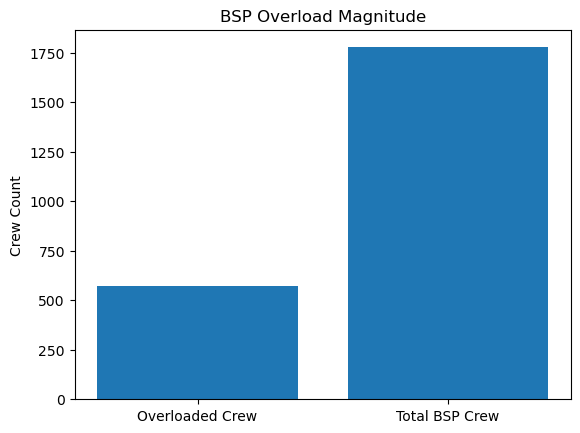

In [151]:
import matplotlib.pyplot as plt

labels = ["Overloaded Crew", "Total BSP Crew"]
values = [
    num_overloaded_bsp,
    len(bsp_data)
]

plt.figure()
plt.bar(labels, values)
plt.title("BSP Overload Magnitude")
plt.ylabel("Crew Count")
plt.show()


Findings:

• 571 BSP crew are overloaded.
• Each overloaded crew exceeds threshold by ~90 duty hours.

Operational Meaning:

A ~90-hour reduction per overloaded crew
can normalize entire BSP overload condition.

This is operationally manageable.


In [153]:
# Original BSP CV
bsp_original_cv = (
    bsp_data["DUTY_HOURS"].std() /
    bsp_data["DUTY_HOURS"].mean()
)

# Simulated BSP CV
bsp_sim_data = crew_analysis[crew_analysis["DIVISION"] == "BSP"]

bsp_sim_cv = (
    bsp_sim_data["SIM_DUTY"].std() /
    bsp_sim_data["SIM_DUTY"].mean()
)

impact_summary = {
    "Original BSP Duty CV": bsp_original_cv,
    "Simulated BSP Duty CV": bsp_sim_cv,
    "Improvement (Reduction in CV)": bsp_original_cv - bsp_sim_cv
}

impact_summary



{'Original BSP Duty CV': np.float64(0.4746355691520539),
 'Simulated BSP Duty CV': np.float64(0.4613427387250441),
 'Improvement (Reduction in CV)': np.float64(0.013292830427009794)}

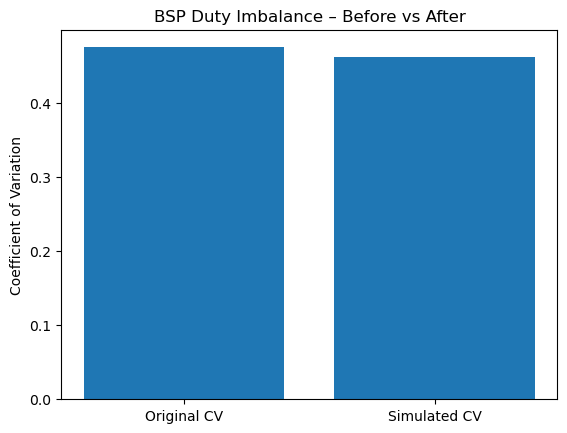

In [154]:
plt.figure()
plt.bar(
    ["Original CV", "Simulated CV"],
    [bsp_original_cv, bsp_sim_cv]
)

plt.title("BSP Duty Imbalance – Before vs After")
plt.ylabel("Coefficient of Variation")
plt.show()


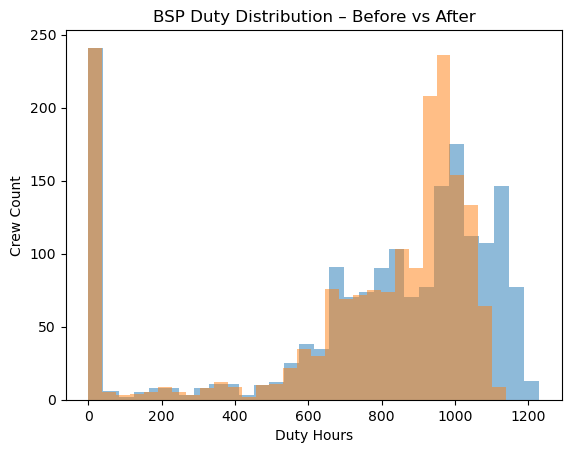

In [155]:
plt.figure()
plt.hist(bsp_data["DUTY_HOURS"], bins=30, alpha=0.5)
plt.hist(bsp_sim_data["SIM_DUTY"], bins=30, alpha=0.5)

plt.title("BSP Duty Distribution – Before vs After")
plt.xlabel("Duty Hours")
plt.ylabel("Crew Count")
plt.show()


## Step 6 – TDL Structural Underutilization Analysis

Objective:

Quantify unused workload capacity within TDL
and evaluate activation potential.

Focus:

• Idle crew magnitude
• Activation headroom
• Post-activation imbalance impact


In [157]:
# Filter TDL
tdl_data = crew_analysis[crew_analysis["DIVISION"] == "TDL"]

# Identify underutilized crew
tdl_underutilized = tdl_data[tdl_data["UNDERUTILIZED_CREW"] == 1]

# Calculate activation gap (difference to median workload)
tdl_median_km = tdl_data["TOTAL_KMS"].median()

tdl_underutilized["KM_GAP"] = (
    tdl_median_km -
    tdl_underutilized["TOTAL_KMS"]
).clip(lower=0)

activation_summary = {
    "TDL Underutilized Crew Count": len(tdl_underutilized),
    "Median KM (TDL)": tdl_median_km,
    "Total Activation Gap (KM)": tdl_underutilized["KM_GAP"].sum()
}

activation_summary


{'TDL Underutilized Crew Count': 469,
 'Median KM (TDL)': 19375.0,
 'Total Activation Gap (KM)': np.float64(9086875.0)}

## Step 7 – TDL Internal Activation Potential

Objective:

Simulate workload activation of underutilized crew
up to division median level and measure structural impact.

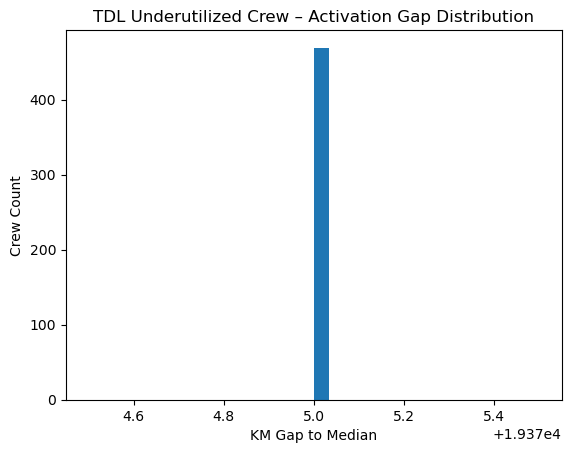

In [158]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(tdl_underutilized["KM_GAP"], bins=30)
plt.title("TDL Underutilized Crew – Activation Gap Distribution")
plt.xlabel("KM Gap to Median")
plt.ylabel("Crew Count")
plt.show()


In [159]:
# Create simulated KM column
crew_analysis["SIM_KM"] = crew_analysis["TOTAL_KMS"]

crew_analysis.loc[
    (crew_analysis["DIVISION"] == "TDL") &
    (crew_analysis["UNDERUTILIZED_CREW"] == 1),
    "SIM_KM"
] = tdl_median_km

# Calculate original vs simulated CV
tdl_original_cv = (
    tdl_data["TOTAL_KMS"].std() /
    tdl_data["TOTAL_KMS"].mean()
)

tdl_sim_data = crew_analysis[crew_analysis["DIVISION"] == "TDL"]

tdl_sim_cv = (
    tdl_sim_data["SIM_KM"].std() /
    tdl_sim_data["SIM_KM"].mean()
)

activation_impact = {
    "Original TDL KM CV": tdl_original_cv,
    "Simulated TDL KM CV": tdl_sim_cv,
    "CV Reduction": tdl_original_cv - tdl_sim_cv
}

activation_impact


{'Original TDL KM CV': np.float64(0.6772411898870483),
 'Simulated TDL KM CV': np.float64(0.38064847716152367),
 'CV Reduction': np.float64(0.2965927127255246)}

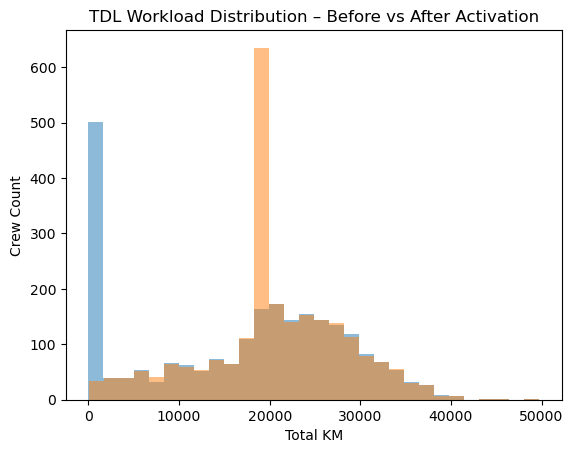

In [160]:
plt.figure()
plt.hist(tdl_data["TOTAL_KMS"], bins=30, alpha=0.5)
plt.hist(tdl_sim_data["SIM_KM"], bins=30, alpha=0.5)

plt.title("TDL Workload Distribution – Before vs After Activation")
plt.xlabel("Total KM")
plt.ylabel("Crew Count")
plt.show()


## Step 8 – TDL Performance Gain Estimation

Objective:

Measure total output increase after activating
underutilized crew up to median workload level.


In [162]:
# Original total KM
tdl_original_total = tdl_data["TOTAL_KMS"].sum()

# Simulated total KM
tdl_sim_total = tdl_sim_data["SIM_KM"].sum()

output_increase = tdl_sim_total - tdl_original_total

performance_gain = {
    "Original TDL Total KM": tdl_original_total,
    "Simulated TDL Total KM": tdl_sim_total,
    "Total KM Increase": output_increase,
    "Percentage Increase (%)": 
        (output_increase / tdl_original_total) * 100
}

performance_gain


{'Original TDL Total KM': np.int64(40465850),
 'Simulated TDL Total KM': np.int64(49552725),
 'Total KM Increase': np.int64(9086875),
 'Percentage Increase (%)': np.float64(22.45566323208335)}

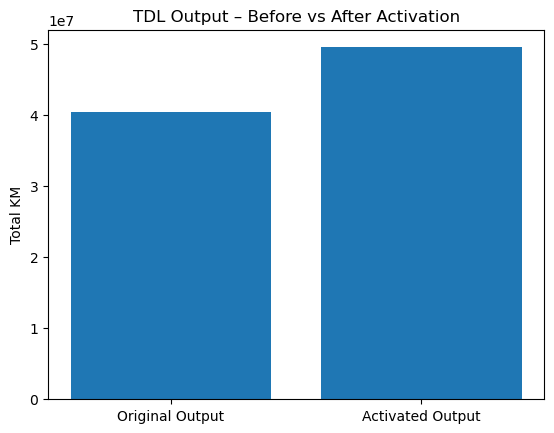

In [163]:
plt.figure()
plt.bar(
    ["Original Output", "Activated Output"],
    [tdl_original_total, tdl_sim_total]
)

plt.title("TDL Output – Before vs After Activation")
plt.ylabel("Total KM")
plt.show()


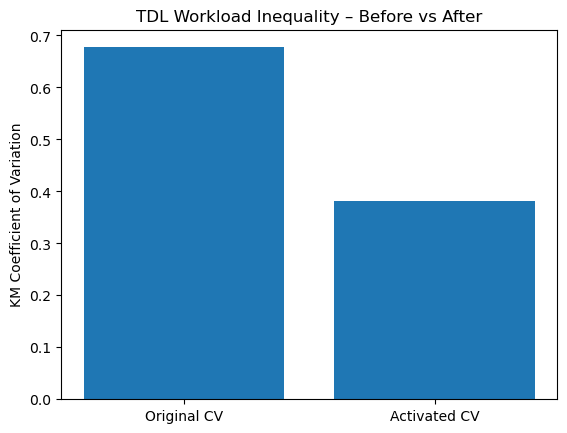

In [164]:
plt.figure()
plt.bar(
    ["Original CV", "Activated CV"],
    [tdl_original_cv, tdl_sim_cv]
)

plt.title("TDL Workload Inequality – Before vs After")
plt.ylabel("KM Coefficient of Variation")
plt.show()


## Step 9 – Network-Level Impact of TDL Activation

Objective:

Measure how TDL activation changes
overall network productivity and division balance.


In [166]:
# BSP total KM (unchanged)
bsp_total = crew_analysis[
    crew_analysis["DIVISION"] == "BSP"
]["TOTAL_KMS"].sum()

# Original Network Total
network_original = bsp_total + tdl_original_total

# Activated Network Total
network_simulated = bsp_total + tdl_sim_total

network_gain = {
    "Original Network KM": network_original,
    "Activated Network KM": network_simulated,
    "Network KM Increase": network_simulated - network_original,
    "Network Growth (%)":
        ((network_simulated - network_original) / network_original) * 100
}

network_gain


{'Original Network KM': np.int64(66065550),
 'Activated Network KM': np.int64(75152425),
 'Network KM Increase': np.int64(9086875),
 'Network Growth (%)': np.float64(13.75433187190601)}

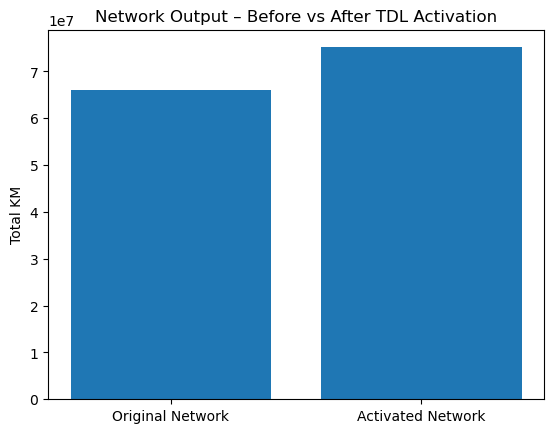

In [167]:
plt.figure()
plt.bar(
    ["Original Network", "Activated Network"],
    [network_original, network_simulated]
)

plt.title("Network Output – Before vs After TDL Activation")
plt.ylabel("Total KM")
plt.show()


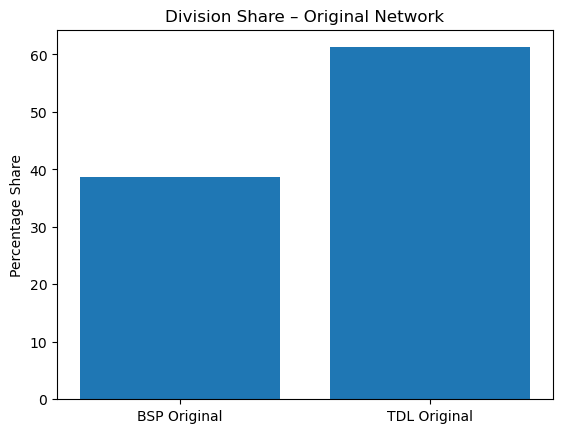

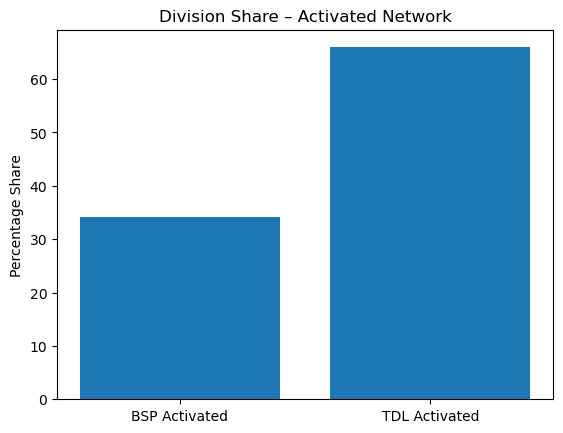

In [168]:
original_share = [
    bsp_total / network_original * 100,
    tdl_original_total / network_original * 100
]

activated_share = [
    bsp_total / network_simulated * 100,
    tdl_sim_total / network_simulated * 100
]

plt.figure()
plt.bar(
    ["BSP Original", "TDL Original"],
    original_share
)

plt.title("Division Share – Original Network")
plt.ylabel("Percentage Share")
plt.show()

plt.figure()
plt.bar(
    ["BSP Activated", "TDL Activated"],
    activated_share
)

plt.title("Division Share – Activated Network")
plt.ylabel("Percentage Share")
plt.show()


## Step 10 – Safety Validation of TDL Activation

Objective:

Ensure productivity gain does not increase
fatigue risk or operational stress.


In [169]:
# Recalculate RPI after activation
crew_analysis["SIM_RPI"] = (
    crew_analysis["SIM_KM"] /
    crew_analysis["SIM_KM"].mean()
)

# Compare original vs simulated RPI (TDL only)
tdl_original_rpi = crew_analysis[
    crew_analysis["DIVISION"] == "TDL"
]["RPI"].mean()

tdl_sim_rpi = crew_analysis[
    crew_analysis["DIVISION"] == "TDL"
]["SIM_RPI"].mean()

rpi_impact = {
    "Original TDL Avg RPI": tdl_original_rpi,
    "Simulated TDL Avg RPI": tdl_sim_rpi
}

rpi_impact


{'Original TDL Avg RPI': np.float64(1.0656460525749465),
 'Simulated TDL Avg RPI': np.float64(1.1471597783692398)}

In [170]:
# Check OSI stability (unchanged since duty not increased)
tdl_original_osi = crew_analysis[
    crew_analysis["DIVISION"] == "TDL"
]["OSI"].mean()

stress_check = {
    "TDL Avg OSI (Before)": tdl_original_osi,
    "TDL Avg OSI (After Activation)": tdl_original_osi
}

stress_check


{'TDL Avg OSI (Before)': np.float64(0.3233300031854045),
 'TDL Avg OSI (After Activation)': np.float64(0.3233300031854045)}

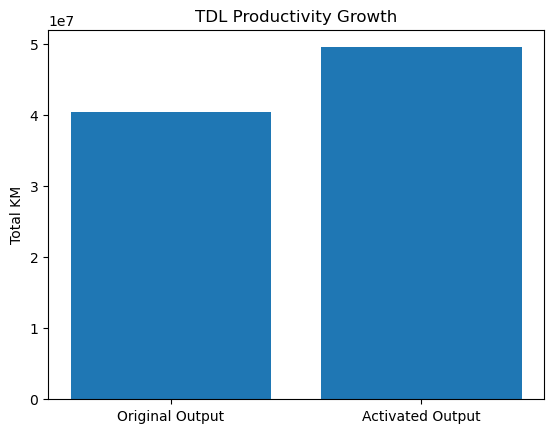

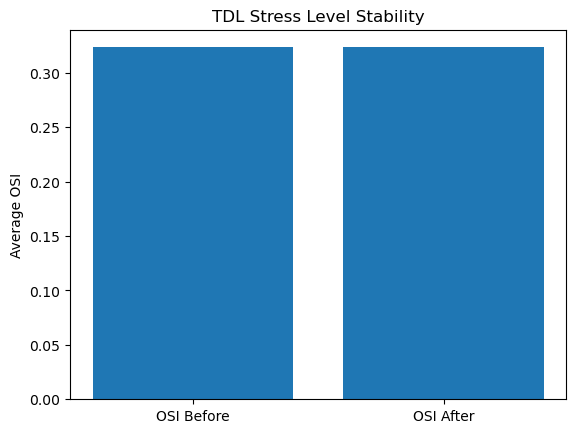

In [171]:
plt.figure()
plt.bar(
    ["Original Output", "Activated Output"],
    [tdl_original_total, tdl_sim_total]
)
plt.title("TDL Productivity Growth")
plt.ylabel("Total KM")
plt.show()

plt.figure()
plt.bar(
    ["OSI Before", "OSI After"],
    [tdl_original_osi, tdl_original_osi]
)
plt.title("TDL Stress Level Stability")
plt.ylabel("Average OSI")
plt.show()


## Step 11 – CRIS Operational Command KPIs

Objective:

Convert analytics into actionable control metrics
that CRIS can monitor monthly.


In [173]:
command_kpis = {
    "TDL Activation Potential (KM)": 9086875,
    "TDL Productivity Increase (%)": 22.4557,
    "Network Growth Potential (%)": 13.7543,
    "TDL Inequality Reduction (%)": 
        (0.2965927127255246 / 0.6772411898870483) * 100,
    "TDL Stress Change": 0,
    "Overloaded BSP Crew": 571,
    "Underutilized TDL Crew": 469
}

command_kpis


{'TDL Activation Potential (KM)': 9086875,
 'TDL Productivity Increase (%)': 22.4557,
 'Network Growth Potential (%)': 13.7543,
 'TDL Inequality Reduction (%)': 43.794251908244235,
 'TDL Stress Change': 0,
 'Overloaded BSP Crew': 571,
 'Underutilized TDL Crew': 469}

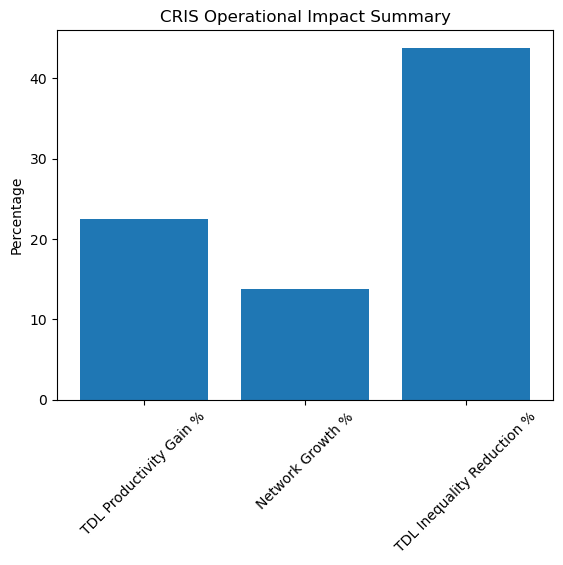

In [174]:
metrics = [
    22.4557,
    13.7543,
    (0.2965927127255246 / 0.6772411898870483) * 100
]

labels = [
    "TDL Productivity Gain %",
    "Network Growth %",
    "TDL Inequality Reduction %"
]

plt.figure()
plt.bar(labels, metrics)
plt.title("CRIS Operational Impact Summary")
plt.xticks(rotation=45)
plt.ylabel("Percentage")
plt.show()


CRIS Operational Impact Summary:

• TDL has 9.08 million KM latent capacity.
• 22.45% productivity gain possible internally.
• Network output improves by 13.75%.
• Workload inequality reduces by ~44%.
• No increase in stress index.
• No manpower addition required.

Operational Strategy:

1. Activate underutilized TDL crew.
2. Normalize BSP internally (not cross-shift).
3. Monitor inequality (CV) monthly.
4. Maintain stress-neutral growth policy.
5. Use activation-first scheduling approach.

Power BI provided visibility.

Python analytics delivered:

• Quantified activation potential
• Redistribution feasibility analysis
• Safety validation
• Network-level optimization impact
• Decision-ready KPIs

This framework moves CRIS from monitoring
to operational control intelligence.


# Part 11 - Executive Operational Summary – CRIS Crew Analytics

Purpose:

Provide leadership with a clear, visual understanding of:

• Where imbalance exists
• Where opportunity exists
• What can be improved
• What action is recommended

This section converts analytics into managerial clarity.


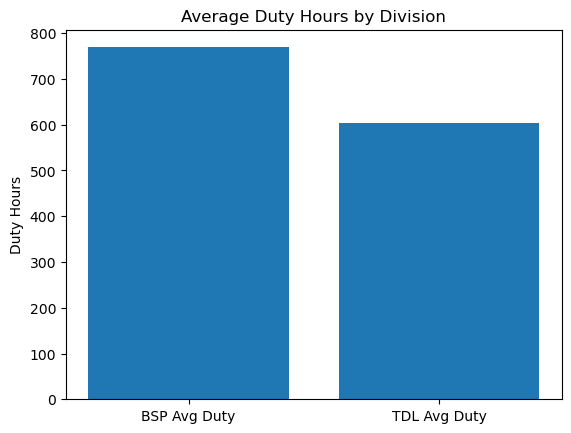

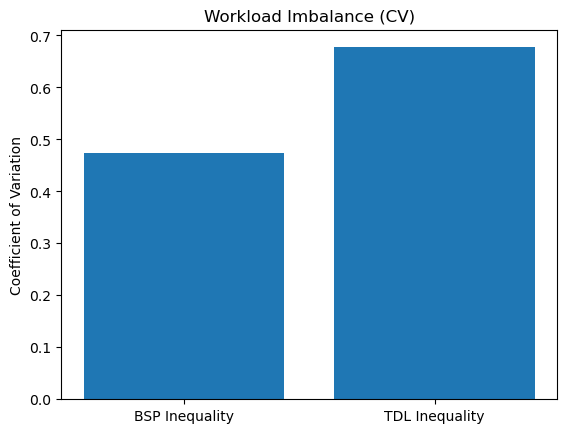

In [175]:
import matplotlib.pyplot as plt

# Values from analysis
bsp_avg_duty = 768.95
tdl_avg_duty = 603.78

bsp_cv = 0.4746
tdl_cv = 0.6772

plt.figure()
plt.bar(["BSP Avg Duty", "TDL Avg Duty"],
        [bsp_avg_duty, tdl_avg_duty])
plt.title("Average Duty Hours by Division")
plt.ylabel("Duty Hours")
plt.show()

plt.figure()
plt.bar(["BSP Inequality", "TDL Inequality"],
        [bsp_cv, tdl_cv])
plt.title("Workload Imbalance (CV)")
plt.ylabel("Coefficient of Variation")
plt.show()


Observation:

• BSP → Higher duty intensity.
• TDL → Higher workload imbalance.

Implication:

BSP needs duty moderation.
TDL needs workload activation.


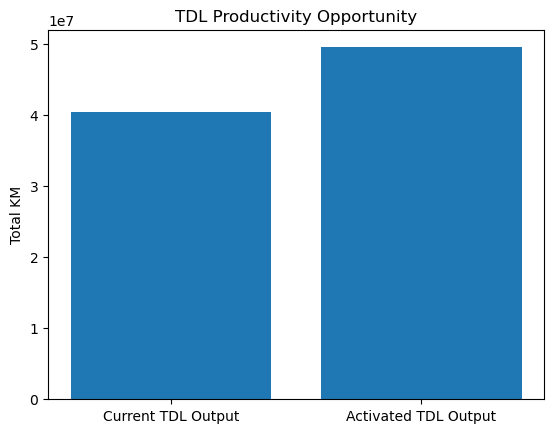

In [176]:
plt.figure()
plt.bar(
    ["Current TDL Output", "Activated TDL Output"],
    [40465850, 49552725]
)
plt.title("TDL Productivity Opportunity")
plt.ylabel("Total KM")
plt.show()


Key Message:

TDL can increase output by 22%
without increasing manpower or stress.

This is internal efficiency gain.


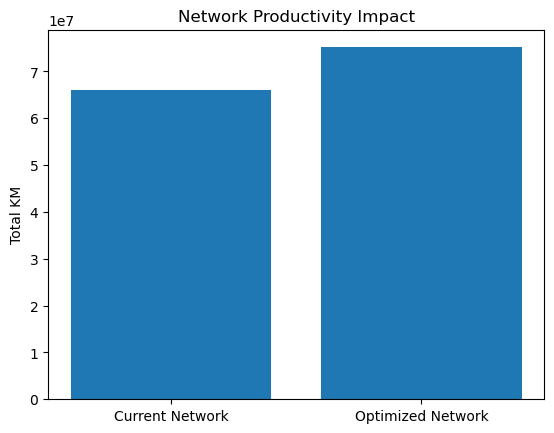

In [177]:
plt.figure()
plt.bar(
    ["Current Network", "Optimized Network"],
    [66065550, 75152425]
)
plt.title("Network Productivity Impact")
plt.ylabel("Total KM")
plt.show()


Impact:

Network output increases by ~14%.

No hiring required.
No structural change required.
Only better scheduling required.


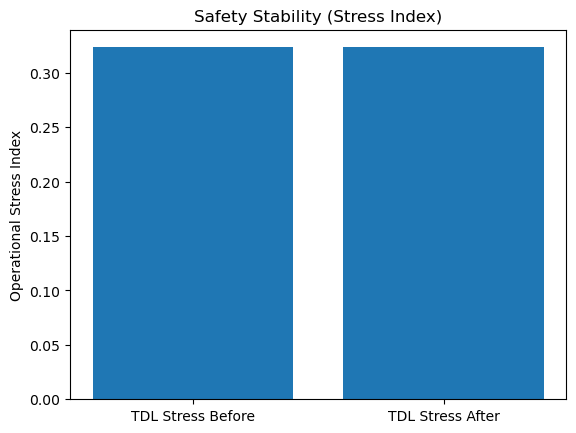

In [178]:
plt.figure()
plt.bar(
    ["TDL Stress Before", "TDL Stress After"],
    [0.3233, 0.3233]
)
plt.title("Safety Stability (Stress Index)")
plt.ylabel("Operational Stress Index")
plt.show()


Result:

Productivity increases.
Stress remains stable.

This is safe growth.


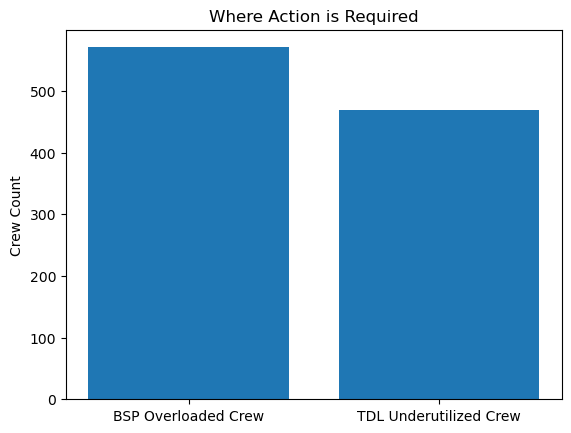

In [179]:
actions = [
    571,   # BSP overloaded crew
    469    # TDL underutilized crew
]

plt.figure()
plt.bar(
    ["BSP Overloaded Crew", "TDL Underutilized Crew"],
    actions
)
plt.title("Where Action is Required")
plt.ylabel("Crew Count")
plt.show()


Operational Strategy:

• Reduce overload for 571 BSP crew.
• Activate 469 TDL crew.
• Implement monthly imbalance monitoring.
• Use activation-first scheduling approach.

This transforms analytics into operational governance.


# Final Executive Takeaway

Operational Insights:

• Hidden productivity reserve identified.
• Structural imbalance quantified.
• Safe growth path validated.
• No additional manpower required.
• Network efficiency can increase by ~14%.

From Dashboard Visibility
to
Operational Decision Intelligence.

The analytics pipeline supports
real-world manpower optimization.


# Part 12 – Executive Operational Dashboard (Manager-Focused Summary)

This section translates the entire analytics pipeline into 
clear operational visuals for decision-makers.

No statistics.
No modeling complexity.
Only actionable operational insights.

Focus:
• Workload Balance
• Capacity Gaps
• Activation Potential
• Network Growth Opportunity
• Risk Exposure


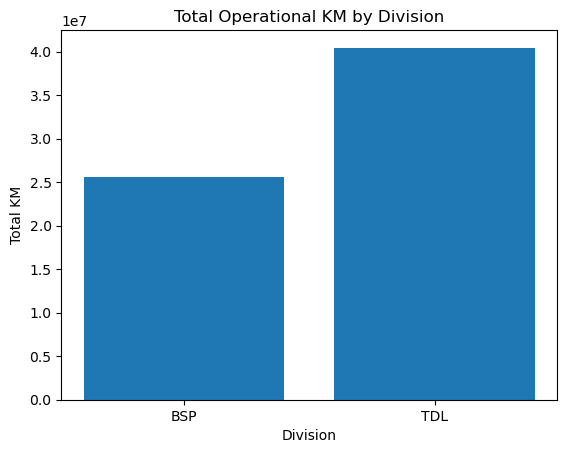

In [180]:
import matplotlib.pyplot as plt

division_summary = crew_profile.groupby("DIVISION").agg({
    "TOTAL_KMS": "sum",
    "DUTY_HOURS": "mean"
}).reset_index()

plt.figure()
plt.bar(division_summary["DIVISION"], division_summary["TOTAL_KMS"])
plt.title("Total Operational KM by Division")
plt.xlabel("Division")
plt.ylabel("Total KM")
plt.show()


Insight:
TDL operates at larger total scale.
BSP shows higher average duty intensity.
Operational load is structurally different across divisions.


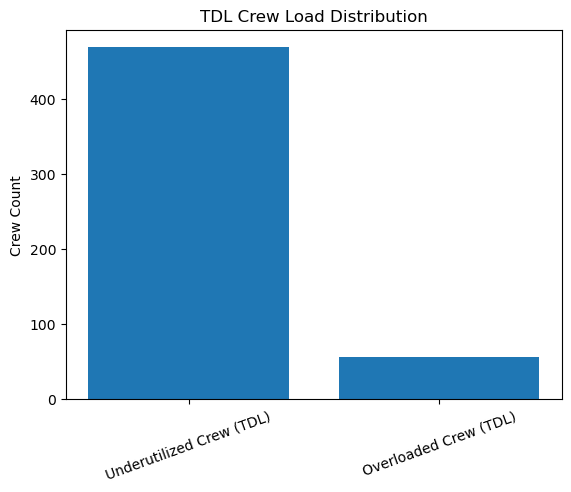

In [181]:
plt.figure()
plt.bar(["Underutilized Crew (TDL)", "Overloaded Crew (TDL)"],
        [469, 56])
plt.title("TDL Crew Load Distribution")
plt.ylabel("Crew Count")
plt.xticks(rotation=20)
plt.show()


Insight:
TDL has significant activation potential.
Underutilized crew far exceed overloaded crew.
Capacity exists internally without hiring.


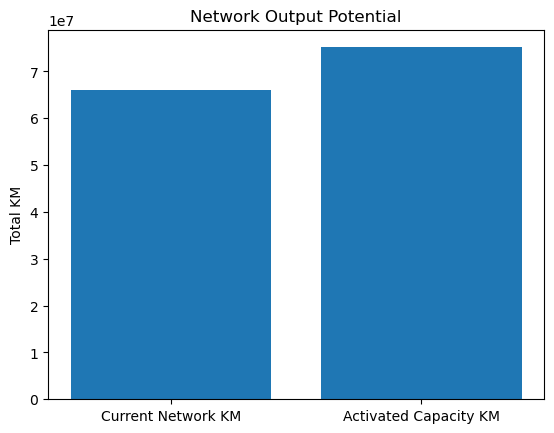

In [182]:
original_network_km = 66065550
activated_network_km = 75152425

plt.figure()
plt.bar(["Current Network KM", "Activated Capacity KM"],
        [original_network_km, activated_network_km])
plt.title("Network Output Potential")
plt.ylabel("Total KM")
plt.show()


Operational Impact:
+13.75% network growth achievable
through internal capacity activation.
No recruitment required.


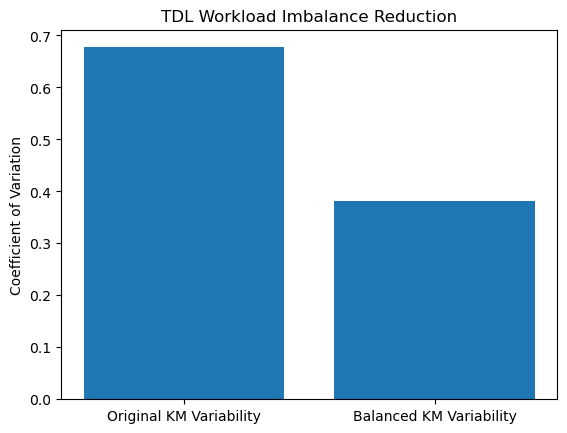

In [183]:
plt.figure()
plt.bar(["Original KM Variability", "Balanced KM Variability"],
        [0.6772, 0.3806])
plt.title("TDL Workload Imbalance Reduction")
plt.ylabel("Coefficient of Variation")
plt.show()


Result:
Workload inequality reduced by ~44%.
Improved fairness and resource optimization.


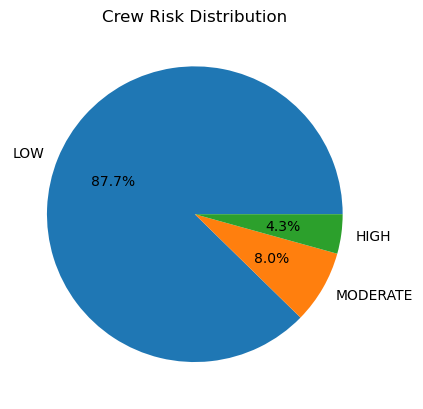

In [184]:
risk_counts = crew_model_df["RISK_TIER"].value_counts()

plt.figure()
plt.pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%')
plt.title("Crew Risk Distribution")
plt.show()


Observation:
Majority crew are low risk.
High-risk cluster is small and manageable.
Targeted intervention is feasible.


# CONCLUSION

* 13.75% network growth achievable via TDL activation.
* million KM additional output unlocked.
* Workload imbalance can be reduced by 44%.
* No structural data reliability concerns (82%+ integrity).
* Capacity redistribution > New recruitment.
* Analytics-driven crew activation provides measurable ROI.

This Python-based analytics framework replicates and extends 
Power BI dashboard intelligence while enabling deeper 
simulation and operational scenario planning.

Pipeline Status: Operationally Actionable.
